# Cook Strait SFT — Nonlinear FEM: Static and Dynamic Assessment

In [13]:
#cell 1
import numpy as np
import scipy.linalg as scp
import matplotlib.pylab as plt
import time
import requests
import scipy.sparse as sp
from io import BytesIO
from mpl_toolkits.mplot3d import Axes3D
from scipy.interpolate import RegularGridInterpolator
import subprocess
subprocess.run(['pip', 'install', 'rasterio'], check=True)
from matplotlib.pylab import rcParams
rcParams['figure.figsize'] = 15, 6
pass

## 1. Tunnel Geometry

In [14]:

from matplotlib import rcParams
rcParams['figure.figsize'] = 15, 6

#Constants 
TunRad   = 58_940      # radius of curvature [m]
cc_space = 18.5        # centre-to-centre tube spacing [m]
z0       = -47.5       # tunnel axis depth [m]
Lb       = 192.0       # mooring bay spacing [m] — used later for node count

#Angular span 
ang_start_deg = 320.00   # Wellington portal
ang_end_deg   = 252.72   # Blenheim portal
total_ang_deg = ang_start_deg - ang_end_deg   # 67.28 deg
total_arc_m   = TunRad * np.radians(total_ang_deg)

print(f"Full tunnel arc (incl. portals): {total_arc_m/1000:.2f} km")

#Full arc coordinates 
n_full_temp = int(np.ceil(total_arc_m / 10)) + 1
ang_full    = np.linspace(ang_start_deg, ang_end_deg, n_full_temp)

TunCX_full = TunRad * np.cos(np.deg2rad(ang_full))
TunCY_full = TunRad * np.sin(np.deg2rad(ang_full))
TunCY_full = TunCY_full - TunCY_full.min()
TunCZ_full = np.full(n_full_temp, z0)

TunCX2_full = TunCX_full + cc_space
TunCY2_full = TunCY_full.copy()
TunCZ2_full = TunCZ_full.copy()

# Arc-length along full alignment
arc_s_full = np.linspace(0, total_arc_m, n_full_temp)

print(f"Dense arc array for GEBCO lookup: {n_full_temp} points at ~10 m spacing")
print(f"Tube 1 x range: {TunCX_full.min()/1000:.1f} to "
      f"{TunCX_full.max()/1000:.1f} km")
print(f"Tube 1 y range: {TunCY_full.min()/1000:.1f} to "
      f"{TunCY_full.max()/1000:.1f} km")

Full tunnel arc (incl. portals): 69.21 km
Dense arc array for GEBCO lookup: 6923 points at ~10 m spacing
Tube 1 x range: -17.5 to 45.2 km
Tube 1 y range: 0.0 to 21.1 km


## 2. Section Properties

In [15]:
#cell 3
import math


# Material — reinforced concrete
E   = 36e9    
nu  = 0.22    # Poisson ratio
G   = E / (2*(nu + 1))
rho = 2500    # concrete density [kg/m³]

# ── Circular tube geometry
r_o = 7.5          # outer radius [m]  (D = 15 m)
r_i = 7.5 - 0.8    # inner radius [m]  (wall thickness t = 0.8 m)

Area_shell = math.pi * (r_o**2 - r_i**2)      # annular shell area [m²]
I_shell    = (math.pi/4) * (r_o**4 - r_i**4)  # second moment of area [m⁴]

# ── Internal floors/walls (road deck + ceiling, t = 0.2 m each)
width_road    = math.sqrt(r_i**2 - 2.25**2) * 2   # clear road width [m]
thick_road    = 0.2                                 # [m]
Area_internal = width_road * thick_road * 2        # road deck + ceiling [m²]
# Iz (about horizontal axis) — two horizontal plates
I_road_z = thick_road * width_road**3 / 12 * 2
# Iy (about vertical axis) — parallel axis theorem: plates offset ±2.25 m
I_road_y = (width_road * thick_road**3/12 + width_road * thick_road * (2.25 + thick_road/2)**2) * 2

Area = Area_shell + Area_internal
Iz   = I_shell  + I_road_z
Iy   = I_shell  + I_road_y
J    = I_shell  * 2    # polar moment

print(f"Outer diameter D  = {2*r_o:.1f} m")
print(f"Wall thickness t  = {r_o-r_i:.2f} m")
print(f"Area (A)          = {Area:.2f} m²")
print(f"Iz                = {Iz:.2f} m⁴")
print(f"Iy                = {Iy:.2f} m⁴")
print(f"J (torsion)       = {J:.2f} m⁴")

rho_water = 1025  # seawater density [kg/m³]

Beam_EA  = E * Area
Beam_EIy = E * Iy
Beam_EIz = E * Iz
Beam_GJ  = G * J
Beam_m   = Area * rho

Ab_per_tube = 9.83
rho_ballast = 38e3 / 9.81
ballast_mass_per_m = Ab_per_tube * rho_ballast
Beam_m_total = Beam_m + ballast_mass_per_m
Beam_Im = J / Area



weight_per_meter   = Beam_m * 9.81
buoyancy_per_meter = rho_water * math.pi * r_o**2 * 9.81
net_vertical       = buoyancy_per_meter - weight_per_meter
tunnel_depth_z   = -55.0  
#Ballast
print(f"\nMass breakdown per metre (one tube):")
print(f"  Structural (concrete)  : {Beam_m:.1f} kg/m")
print(f"  Iron-ore ballast       : {ballast_mass_per_m:.1f} kg/m")
print(f"  Total structural mass  : {Beam_m_total:.1f} kg/m")
print(f"  Added mass (ρw·π·r²)   : {rho_water*math.pi*r_o**2:.1f} kg/m")
print(f"\nNet buoyancy before ballast: {net_vertical/1e3:.2f} kN/m (positive = upward)")


Outer diameter D  = 15.0 m
Wall thickness t  = 0.80 m
Area (A)          = 40.74 m²
Iz                = 969.41 m⁴
Iy                = 930.28 m⁴
J (torsion)       = 1804.77 m⁴

Mass breakdown per metre (one tube):
  Structural (concrete)  : 101843.0 kg/m
  Iron-ore ballast       : 38077.5 kg/m
  Total structural mass  : 139920.5 kg/m
  Added mass (ρw·π·r²)   : 181132.5 kg/m

Net buoyancy before ballast: 777.83 kN/m (positive = upward)


GEBCO loaded: (312, 360), depth range [-1650, 1669] m


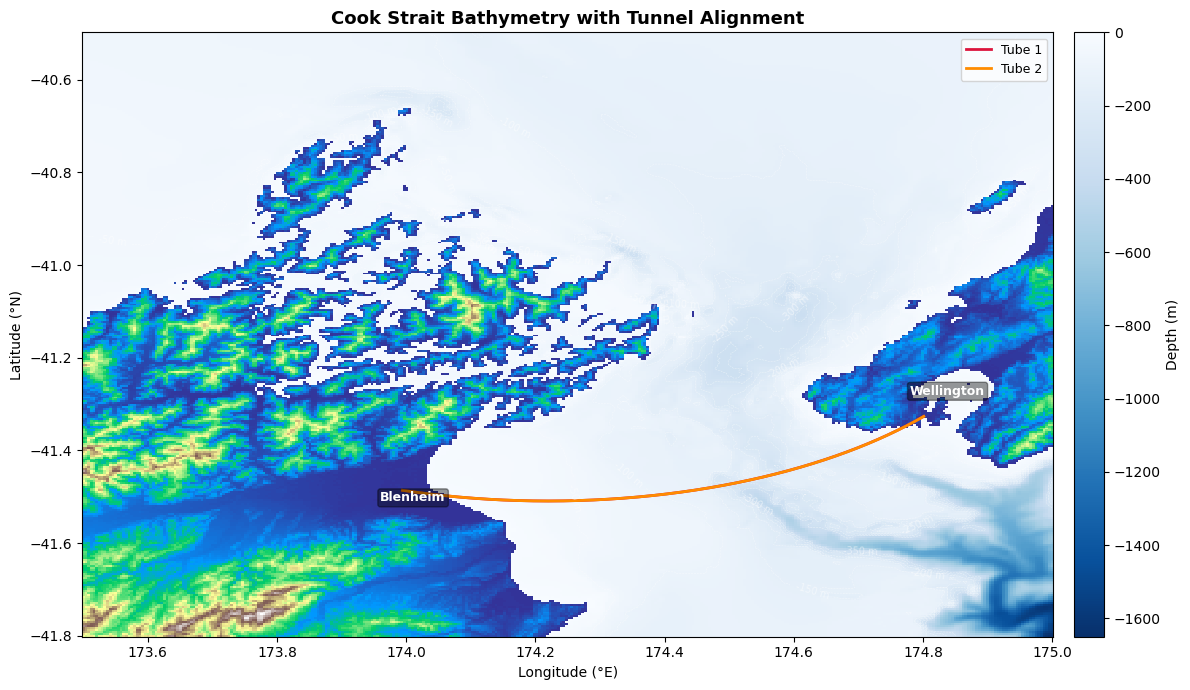

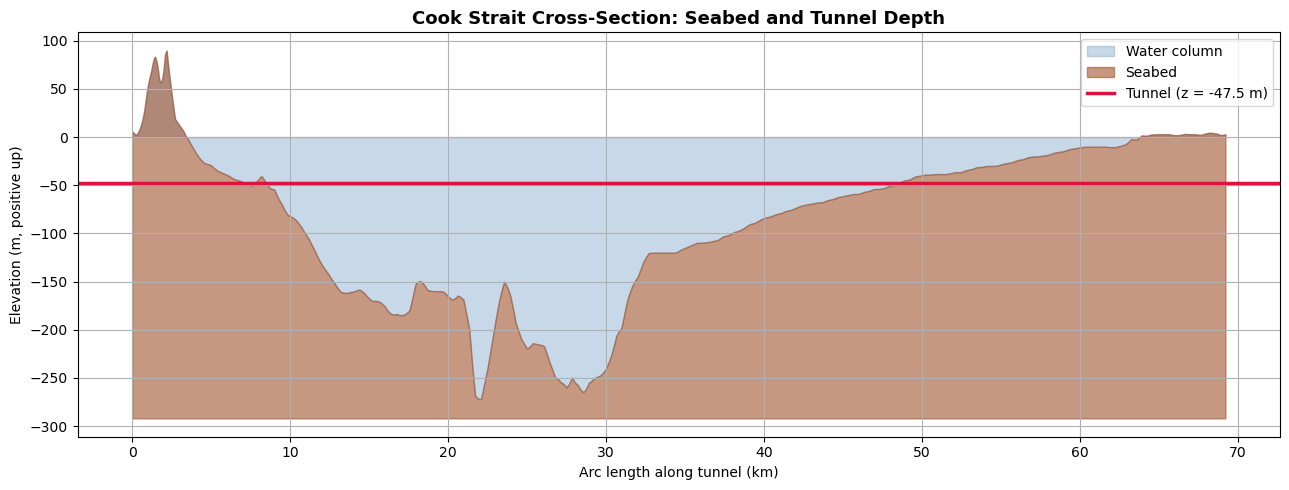

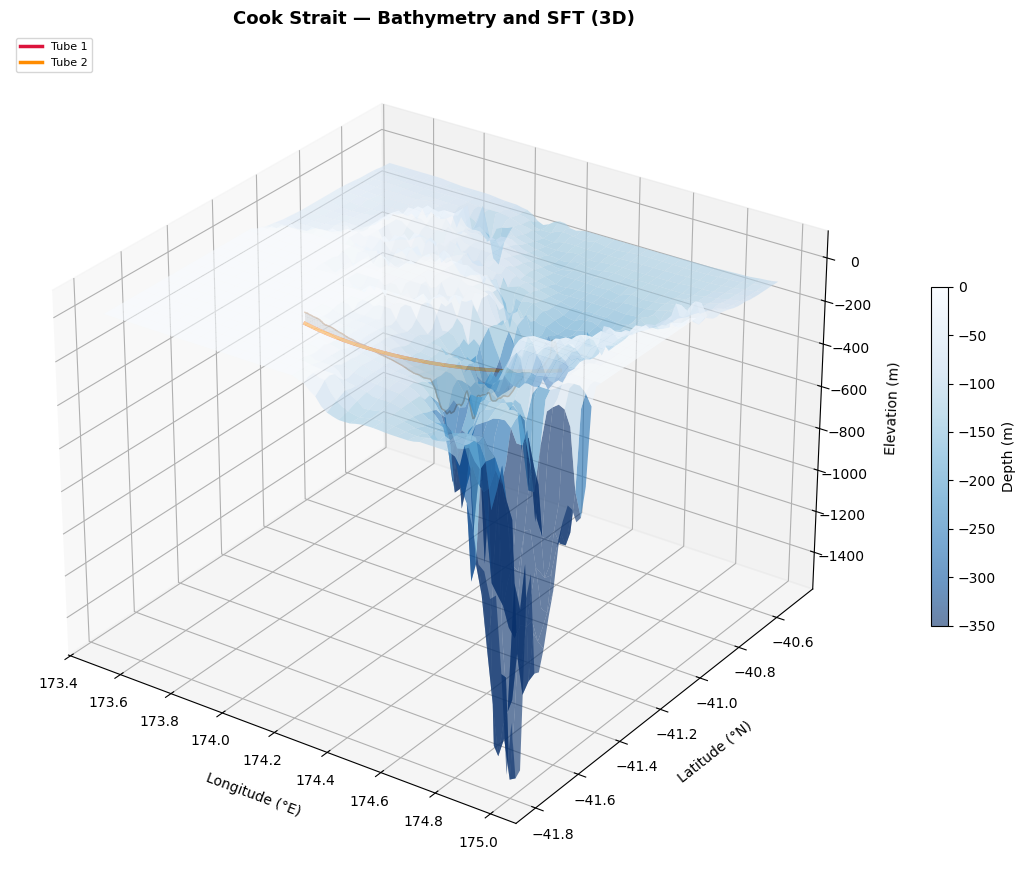

Tunnel depth           : -47.5 m
Seabed depth range     : -272 to 90 m
Clearance above seabed : -137 to 224 m

── Submerged section identified from GEBCO ──────────────
  First submerged node : index 710  (arc = 7.10 km)
  Last  submerged node : index 4853  (arc = 48.52 km)
  Submerged arc length : 41.42 km


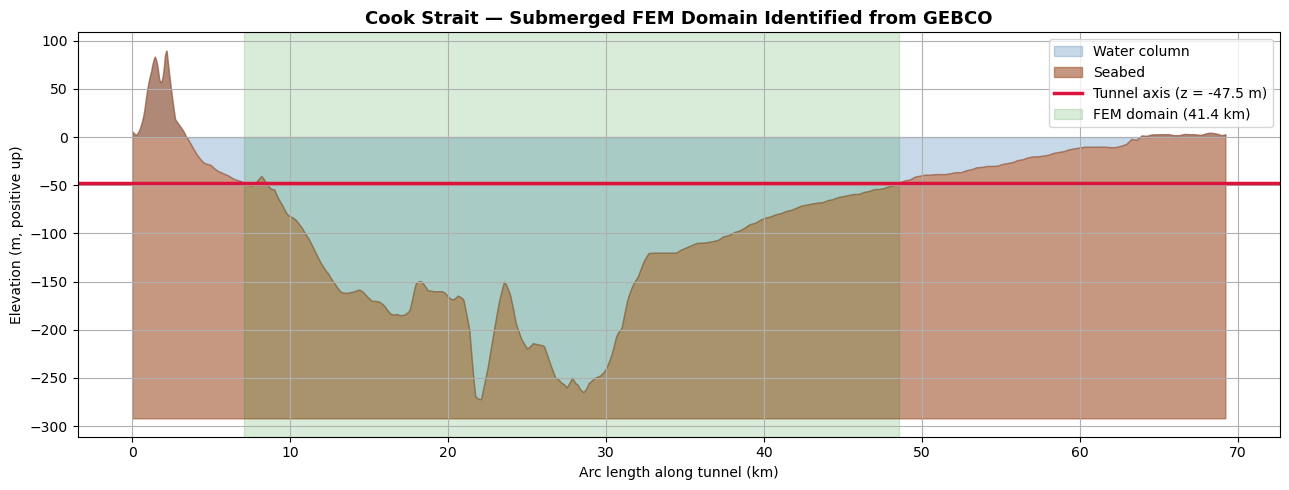

Submerged arc (from GEBCO):      41.42 km
Mooring bay spacing:             192.0 m
Number of complete bays:         216
Nodes per tube:                  433
Element spacing:                 95.89 m  (= Lb/2)
Elements per mooring bay:        2.0
dx/Lc = 0.77 < 1  ✓

───────────────────────────────────────────────────────
  FEM domain summary
───────────────────────────────────────────────────────
  Submerged arc (GEBCO)     : 41.42 km
  Mooring bay spacing       : 192 m
  Complete mooring bays     : 216
  Nodes per tube            : 433
  Total nodes (both tubes)  : 866
  Element spacing           : 95.89 m
  Elements per bay          : 2
  Mooring stations per tube : 217
  Water depth range         : 50 to 272 m
  Tether length range       : 14 to 317 m
───────────────────────────────────────────────────────


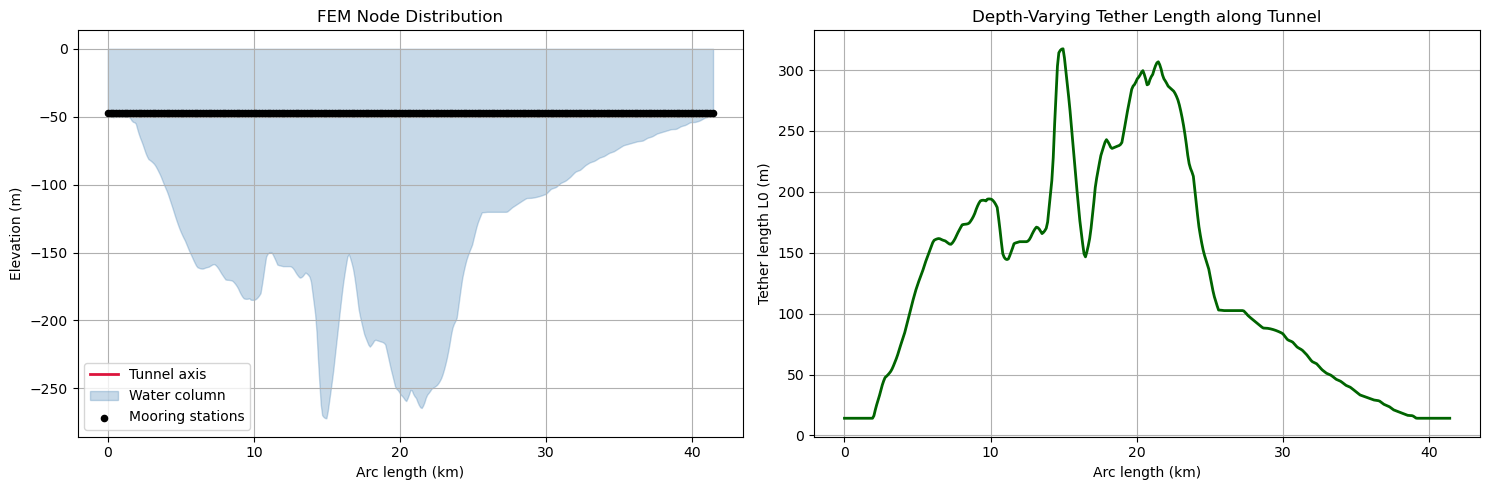

In [16]:

# --- GEBCO fetch ---
lon_min, lon_max = 173.5, 175.0
lat_min, lat_max = -41.8, -40.5

url = (
    "https://www.gebco.net/data_and_products/gebco_web_services/web_map_service/mapserv?"
    "request=GetCoverage&service=WCS&version=1.0.0&coverage=gebco_latest_2"
    f"&BBOX={lon_min},{lat_min},{lon_max},{lat_max}"
    "&CRS=EPSG:4326&format=geotiff&width=300&height=240"
)

import rasterio
with rasterio.open('gebco_2024.tif') as ds:
    bathy_grid = ds.read(1).astype(float)
    lons_grid  = np.linspace(173.5, 175.0, bathy_grid.shape[1])
    lats_grid  = np.linspace(-40.5, -41.8, bathy_grid.shape[0])
gebco_loaded = True
print(f"GEBCO loaded: {bathy_grid.shape}, depth range "
      f"[{bathy_grid.min():.0f}, {bathy_grid.max():.0f}] m")

if not gebco_loaded:
    lons_grid = np.linspace(lon_min, lon_max, 300)
    lats_grid = np.linspace(lat_max, lat_min, 240)
    LON_g, LAT_g = np.meshgrid(lons_grid, lats_grid)
    lon_c = (lon_min + lon_max) / 2
    lat_c = (lat_min + lat_max) / 2
    bathy_grid = -50 - 250 * np.exp(
        -((LON_g - lon_c)**2 / 0.2 + (LAT_g - lat_c)**2 / 0.2))


n_temp  = len(ang_full)
ang_tmp = ang_full

TunCX_tmp = TunRad * np.cos(np.deg2rad(ang_tmp))
TunCY_tmp = TunRad * np.sin(np.deg2rad(ang_tmp))
TunCY_tmp = TunCY_tmp - TunCY_tmp.min()


lon_wellington, lat_wellington = 174.801130, -41.326654
lon_blenheim,   lat_blenheim   = 173.994094, -41.509210

x_range     = TunCX_tmp.max() - TunCX_tmp.min()
y_range     = TunCY_tmp.max() - TunCY_tmp.min()
geo_lon_span = lon_wellington - lon_blenheim
geo_lat_span = lat_wellington - lat_blenheim
sx = geo_lon_span / x_range
sy = geo_lat_span / y_range

node_lons1 = lon_blenheim + (TunCX_tmp - TunCX_tmp.min()) * sx
node_lats1 = lat_blenheim + (TunCY_tmp - TunCY_tmp.min()) * abs(sy) * np.sign(geo_lat_span)
node_lons2 = node_lons1 + cc_space * sx
node_lats2 = node_lats1.copy()

lats_asc = lats_grid[::-1]
grid_asc  = bathy_grid[::-1, :]
interp    = RegularGridInterpolator(
    (lats_asc, lons_grid), grid_asc,
    method='linear', bounds_error=False, fill_value=-100.0)

seabed1 = interp(np.column_stack([node_lats1, node_lons1]))
seabed2 = interp(np.column_stack([node_lats2, node_lons2]))
tunnel_z = -47.5


node_water_depth = -seabed1
node_water_depth = np.maximum(node_water_depth, 50.0)

from scipy.ndimage import uniform_filter1d
node_water_depth = uniform_filter1d(node_water_depth, size=10)


arc = np.zeros(n_temp)
for i in range(1, n_temp):
    dx = TunCX_tmp[i] - TunCX_tmp[i-1]
    dy = TunCY_tmp[i] - TunCY_tmp[i-1]
    arc[i] = arc[i-1] + np.sqrt(dx**2 + dy**2)
arc_km = arc / 1000.0

# Tether geometry per node
alpha_tether   = np.radians(45.0)
h_govern_nodes = np.maximum(node_water_depth - 47.5, 10.0)
L0_nodes       = h_govern_nodes / np.cos(alpha_tether)
r0_nodes       = h_govern_nodes * np.tan(alpha_tether)

# =============================================================================
# PLOT 1 — 2D Bathymetry map
# =============================================================================
LON_plot, LAT_plot = np.meshgrid(lons_grid, lats_grid)
sea  = np.where(bathy_grid <= 0, bathy_grid, np.nan)
land = np.where(bathy_grid >  0, bathy_grid, np.nan)

fig, ax = plt.subplots(figsize=(12, 7))
im_sea = ax.pcolormesh(LON_plot, LAT_plot, sea,
                       cmap='Blues_r', vmin=np.nanmin(sea), vmax=0,
                       shading='auto')
if not np.all(np.isnan(land)):
    ax.pcolormesh(LON_plot, LAT_plot, land,
                  cmap='terrain', vmin=0, vmax=np.nanmax(land),
                  shading='auto')
cs = ax.contour(LON_plot, LAT_plot, sea,
                levels=np.arange(-350, 0, 50),
                colors='white', linewidths=0.4, alpha=0.5)
ax.clabel(cs, fmt='%d m', fontsize=7, colors='white')
ax.plot(node_lons1, node_lats1, color='crimson',    lw=2, label='Tube 1')
ax.plot(node_lons2, node_lats2, color='darkorange', lw=2, label='Tube 2')
plt.colorbar(im_sea, ax=ax, pad=0.02, fraction=0.03, label='Depth (m)')
for name, lo, la in [('Wellington', 174.78, -41.28),
                      ('Blenheim',  173.96, -41.51)]:
    ax.annotate(name, xy=(lo, la), fontsize=9, color='white',
                fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.2', fc='black', alpha=0.4))
ax.set_title('Cook Strait Bathymetry with Tunnel Alignment',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Longitude (°E)')
ax.set_ylabel('Latitude (°N)')
ax.legend(loc='upper right', fontsize=9)
plt.tight_layout()
plt.show()

# =============================================================================
# PLOT 2 — Cross-section
# =============================================================================
fig, ax = plt.subplots(figsize=(13, 5))
ax.fill_between(arc_km, seabed1, 0,
                alpha=0.3, color='steelblue', label='Water column')
ax.fill_between(arc_km, seabed1, seabed1.min() - 20,
                alpha=0.6, color='sienna', label='Seabed')
ax.axhline(tunnel_z, color='crimson', lw=2.5,
           label=f'Tunnel (z = {tunnel_z} m)')
ax.set_xlabel('Arc length along tunnel (km)')
ax.set_ylabel('Elevation (m, positive up)')
ax.set_title('Cook Strait Cross-Section: Seabed and Tunnel Depth',
             fontsize=13, fontweight='bold')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

# =============================================================================
# PLOT 3 — 3D bathymetry
# =============================================================================
Z_plot = np.where(bathy_grid <= 0, bathy_grid, 0)
step   = 5
LON_ds = LON_plot[::step, ::step]
LAT_ds = LAT_plot[::step, ::step]
Z_ds   = Z_plot[::step, ::step]

fig = plt.figure(figsize=(15, 9))
ax  = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(LON_ds, LAT_ds, Z_ds,
                       cmap='Blues_r', vmin=-350, vmax=0,
                       alpha=0.6, linewidth=0, antialiased=True)
ax.plot(node_lons1, node_lats1, seabed1,
        color='saddlebrown', lw=1.0, alpha=0.5)
ax.plot(node_lons2, node_lats2, seabed2,
        color='peru',        lw=1.0, alpha=0.5)
for i in range(0, len(node_lons1), 25):
    ax.plot([node_lons1[i], node_lons1[i]],
            [node_lats1[i], node_lats1[i]],
            [seabed1[i],    tunnel_z],
            color='gray', lw=0.6, alpha=0.4)
ax.plot(node_lons1, node_lats1, np.full_like(node_lons1, tunnel_z),
        color='crimson',    lw=2.5, label='Tube 1')
ax.plot(node_lons2, node_lats2, np.full_like(node_lons2, tunnel_z),
        color='darkorange', lw=2.5, label='Tube 2')
plt.colorbar(surf, ax=ax, shrink=0.4, pad=0.05, label='Depth (m)')
ax.set_xlabel('Longitude (°E)', labelpad=10)
ax.set_ylabel('Latitude (°N)',  labelpad=10)
ax.set_zlabel('Elevation (m)',  labelpad=10)
ax.set_title('Cook Strait — Bathymetry and SFT (3D)',
             fontsize=13, fontweight='bold')
ax.legend(loc='upper left', fontsize=8)
ax.view_init(elev=28, azim=-55)
plt.tight_layout()
plt.show()

print(f"Tunnel depth           : {tunnel_z} m")
print(f"Seabed depth range     : {seabed1.min():.0f} to {seabed1.max():.0f} m")
print(f"Clearance above seabed : "
      f"{(tunnel_z - seabed1).min():.0f} to {(tunnel_z - seabed1).max():.0f} m")

# =============================================================================
# SUBMERGED MASK — added at end of cell 6
# seabed1 < tunnel_z means seabed is deeper than tunnel axis → tunnel is submerged
# =============================================================================
submerged_mask  = seabed1 < tunnel_z   # True where tunnel is in open water

i_sub_start     = int(np.argmax(submerged_mask))
i_sub_end       = int(len(submerged_mask) - np.argmax(submerged_mask[::-1]) - 1)
submerged_arc_m = arc[i_sub_end] - arc[i_sub_start]

print(f"\n── Submerged section identified from GEBCO ──────────────")
print(f"  First submerged node : index {i_sub_start}  "
      f"(arc = {arc[i_sub_start]/1000:.2f} km)")
print(f"  Last  submerged node : index {i_sub_end}  "
      f"(arc = {arc[i_sub_end]/1000:.2f} km)")
print(f"  Submerged arc length : {submerged_arc_m/1000:.2f} km")

# Highlight submerged section on cross-section plot
fig, ax = plt.subplots(figsize=(13, 5))
ax.fill_between(arc_km, seabed1, 0,
                alpha=0.3, color='steelblue', label='Water column')
ax.fill_between(arc_km, seabed1, seabed1.min() - 20,
                alpha=0.6, color='sienna', label='Seabed')
ax.axhline(tunnel_z, color='crimson', lw=2.5,
           label=f'Tunnel axis (z = {tunnel_z} m)')
ax.axvspan(arc_km[i_sub_start], arc_km[i_sub_end],
           alpha=0.15, color='green',
           label=f'FEM domain ({submerged_arc_m/1000:.1f} km)')
ax.set_xlabel('Arc length along tunnel (km)')
ax.set_ylabel('Elevation (m, positive up)')
ax.set_title('Cook Strait — Submerged FEM Domain Identified from GEBCO',
             fontsize=13, fontweight='bold')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

# ── Node count from mooring bay spacing ───────────────────────────────────────
n_bays    = int(np.round(submerged_arc_m / Lb))
n_nodes   = 2 * n_bays + 1
dx_actual = submerged_arc_m / (n_nodes - 1)

print(f"Submerged arc (from GEBCO):      {submerged_arc_m/1000:.2f} km")
print(f"Mooring bay spacing:             {Lb:.1f} m")
print(f"Number of complete bays:         {n_bays}")
print(f"Nodes per tube:                  {n_nodes}")
print(f"Element spacing:                 {dx_actual:.2f} m  (= Lb/2)")
print(f"Elements per mooring bay:        {Lb/dx_actual:.1f}")

# Characteristic mooring length check
Lc = 124.0
if dx_actual < Lc:
    print(f"dx/Lc = {dx_actual/Lc:.2f} < 1  ✓")
else:
    raise ValueError(
        f"Element spacing {dx_actual:.1f} m exceeds "
        f"characteristic mooring length {Lc:.1f} m")

# ── Angular positions of submerged section ────────────────────────────────────
ang_sub_start = ang_full[i_sub_start]
ang_sub_end   = ang_full[i_sub_end]
ang_arr       = np.linspace(ang_sub_start, ang_sub_end, n_nodes)

# ── Tube 1 ────────────────────────────────────────────────────────────────────
TunCX = TunRad * np.cos(np.deg2rad(ang_arr))
TunCY = TunRad * np.sin(np.deg2rad(ang_arr))
TunCY = TunCY - TunCY.min()
TunCZ = np.full(n_nodes, z0)

# ── Tube 2 ────────────────────────────────────────────────────────────────────
TunCX2 = TunCX + cc_space
TunCY2 = TunCY.copy()
TunCZ2 = TunCZ.copy()

# ── Arc-length coordinate ─────────────────────────────────────────────────────
arc_s = np.linspace(0.0, submerged_arc_m, n_nodes)   # [m]

# ── Mooring node indices ──────────────────────────────────────────────────────
mooring_node_indices = np.arange(0, n_nodes, 2)   # every other node = every bay

# ── Node coordinate array (NodeC) for downstream cells ───────────────────────
# Format: [x, y, z] for tube 1 nodes then tube 2 nodes
NodeC = (
    [[TunCX[i],  TunCY[i],  TunCZ[i]]  for i in range(n_nodes)] +
    [[TunCX2[i], TunCY2[i], TunCZ2[i]] for i in range(n_nodes)]
)
nNode = 2 * n_nodes

# ── Combined arrays ───────────────────────────────────────────────────────────
TunCX_all = np.concatenate([TunCX,  TunCX2])
TunCY_all = np.concatenate([TunCY,  TunCY2])
TunCZ_all = np.concatenate([TunCZ,  TunCZ2])

# ── Reinterpolate water depth at new FEM nodes ────────────────────────────────
node_lons_new = np.interp(arc_s,
                           arc[i_sub_start:i_sub_end+1] - arc[i_sub_start],
                           node_lons1[i_sub_start:i_sub_end+1])
node_lats_new = np.interp(arc_s,
                           arc[i_sub_start:i_sub_end+1] - arc[i_sub_start],
                           node_lats1[i_sub_start:i_sub_end+1])

seabed_nodes = interp(np.column_stack([node_lats_new, node_lons_new]))
node_water_depth_new = np.maximum(-seabed_nodes, 50.0)   # min 50 m

# Tether geometry at each FEM node
h_nodes  = np.maximum(node_water_depth_new - abs(z0), 10.0)
L0_nodes = h_nodes / np.cos(np.radians(45.0))
r0_nodes = h_nodes * np.tan(np.radians(45.0))

# ── Summary ───────────────────────────────────────────────────────────────────
print(f"\n{'─'*55}")
print(f"  FEM domain summary")
print(f"{'─'*55}")
print(f"  Submerged arc (GEBCO)     : {submerged_arc_m/1000:.2f} km")
print(f"  Mooring bay spacing       : {Lb:.0f} m")
print(f"  Complete mooring bays     : {n_bays}")
print(f"  Nodes per tube            : {n_nodes}")
print(f"  Total nodes (both tubes)  : {nNode}")
print(f"  Element spacing           : {dx_actual:.2f} m")
print(f"  Elements per bay          : 2")
print(f"  Mooring stations per tube : {len(mooring_node_indices)}")
print(f"  Water depth range         : {node_water_depth_new.min():.0f} "
      f"to {node_water_depth_new.max():.0f} m")
print(f"  Tether length range       : {L0_nodes.min():.0f} "
      f"to {L0_nodes.max():.0f} m")
print(f"{'─'*55}")

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Left: node positions
ax = axes[0]
ax.plot(arc_s/1000, TunCZ, color='crimson', lw=2, label='Tunnel axis')
ax.fill_between(arc_s/1000, -node_water_depth_new, 0,
                alpha=0.3, color='steelblue', label='Water column')
ax.scatter(arc_s[mooring_node_indices]/1000,
           TunCZ[mooring_node_indices],
           s=20, color='black', zorder=5, label='Mooring stations')
ax.set_xlabel('Arc length (km)')
ax.set_ylabel('Elevation (m)')
ax.set_title('FEM Node Distribution')
ax.legend()
ax.grid(True)

# Right: tether length variation
ax2 = axes[1]
ax2.plot(arc_s/1000, L0_nodes, color='darkgreen', lw=2)
ax2.set_xlabel('Arc length (km)')
ax2.set_ylabel('Tether length L0 (m)')
ax2.set_title('Depth-Varying Tether Length along Tunnel')
ax2.grid(True)

plt.tight_layout()
plt.show()

node_water_depth = node_water_depth_new   # used by assembly and mooring cells

In [17]:

NodeC = [[x, y, z] for x, y, z in zip(TunCX, TunCY, TunCZ)]
nNode_tube = len(NodeC)

assert nNode == 2 * nNode_tube, f"nNode mismatch: {nNode} vs {2*nNode_tube}"
Ele_tube = []
for n1, n2 in zip(range(0, nNode_tube-1), range(1, nNode_tube)):
    Ele_tube.append([n1, n2, Beam_m_total, Beam_EA,   # ← always Beam_EA
                     Beam_EIy, Beam_EIz, Beam_GJ, Beam_Im])
NodeC2  = [[x, y, z] for x, y, z in zip(TunCX2, TunCY2, TunCZ2)]
nNode_tube2 = len(NodeC2)
offset2 = nNode_tube

NodeC += NodeC2
nNode  = len(NodeC)

Ele_tube2 = []
Ele_tube2 = []
for n1, n2 in zip(range(0, nNode_tube2-1), range(1, nNode_tube2)):
    Ele_tube2.append([n1 + offset2, n2 + offset2, Beam_m_total, Beam_EA,
                      Beam_EIy, Beam_EIz, Beam_GJ, Beam_Im])

assert all(e[3] == Beam_EA for e in Ele_tube),  "Tube 1: non-uniform beam EA detected"
assert all(e[3] == Beam_EA for e in Ele_tube2), "Tube 2: non-uniform beam EA detected"
print(f"Beam EA verified: all {len(Ele_tube)} tube-1 and "
      f"{len(Ele_tube2)} tube-2 elements use Beam_EA = {Beam_EA:.3e} N")
Ele = Ele_tube + Ele_tube2

# Cross-passage connector elements
connector_factor = 1e-6
Ele2 = [[i, i + offset2, Beam_m_total * 0.1,
         Beam_EA,
         Beam_EIy * connector_factor,
         Beam_EIz * connector_factor,
         Beam_GJ  * connector_factor, Beam_Im]
        for i in range(nNode_tube)]

Ele      = np.array(Ele + Ele2)
nEle     = len(Ele)
nTubeEle = len(Ele_tube) + len(Ele_tube2)


print(f"Nodes per tube (submerged) : {nNode_tube}")
print(f"Total nodes               : {nNode}")
print(f"Tube elements             : {nTubeEle}")
print(f"Connector elements        : {len(Ele2)}")
print(f"Total elements            : {nEle}")

Beam EA verified: all 432 tube-1 and 432 tube-2 elements use Beam_EA = 1.467e+12 N
Nodes per tube (submerged) : 433
Total nodes               : 866
Tube elements             : 864
Connector elements        : 433
Total elements            : 1297


## 5. Element Matrices

In [18]:
#cell 7
def Beam3DMatrices(m, EA, EIy, EIz, GJ, Im, NodeCoord):


    # 1 - calculate length of beam (L) and orientation alpha
    xl = NodeCoord[0][0]    # x-coordinate of left node
    yl = NodeCoord[0][1]    # y-coordinate of left node
    zl = NodeCoord[0][2]    # z-coordinate of left node
    xr = NodeCoord[1][0]    # x-coordinate of right node
    yr = NodeCoord[1][1]    # y-coordinate of rigth node
    zr = NodeCoord[1][2]    # z-coordinate of rigth node
    L = np.sqrt((xr - xl)**2 + (yr - yl)**2 + (zr - zl)**2)    # length
    
    # 2 - calculate transformation matrix T
    C = (xr-xl)/L
    S = (yr-yl)/L
    # T in this is different from T in the above Beam 2D function
    T = np.array([[C, S, 0], [-S, C, 0], [0, 0, 1]])
    
    # Only support rotation in XY plane
    if(abs(zr - zl) > 1e-6):
        print("Error, Only supports rotation in XY plane")
        T = np.array([[1, 0, 0], [0, 1, 0], [0,0,1]])        
    
    T = np.asarray(np.bmat([[T, np.zeros((3,3))], [np.zeros((3, 3)), T]]))    
    T = np.asarray(np.bmat([[T, np.zeros((6,6))], [np.zeros((6, 6)), T]]))    
    # print(T)

    # 3 - calculate local stiffness and matrices
    L2 = L*L
    L3 = L*L2
    K = np.array([[EA/L, 0, 0, 0, 0, 0, -EA/L, 0, 0, 0, 0, 0], 
                  [0, 12*EIz/L3, 0, 0, 0, 6*EIz/L2, 0, -12*EIz/L3, 0, 0, 0, 6*EIz/L2], 
                  [0, 0, 12*EIy/L3, 0, -6*EIy/L2, 0, 0, 0, -12*EIy/L3, 0, -6*EIy/L2, 0], 
                  [0, 0, 0, GJ/L, 0, 0, 0, 0, 0, -GJ/L, 0, 0],
                  [0, 0, -6*EIy/L2, 0, 4*EIy/L, 0, 0, 0, 6*EIy/L2, 0, 2*EIy/L, 0], 
                  [0, 6*EIz/L2, 0, 0, 0, 4*EIz/L, 0, -6*EIz/L2, 0, 0, 0, 2*EIz/L], 
                  [-EA/L, 0, 0, 0, 0, 0, EA/L, 0, 0, 0, 0, 0], 
                  [0, -12*EIz/L3, 0, 0, 0, -6*EIz/L2, 0, 12*EIz/L3, 0, 0, 0, -6*EIz/L2], 
                  [0, 0, -12*EIy/L3, 0, 6*EIy/L2, 0, 0, 0, 12*EIy/L3, 0, 6*EIy/L2, 0], 
                  [0, 0, 0, -GJ/L, 0, 0, 0, 0, 0, GJ/L, 0, 0],                  
                  [0, 0, -6*EIy/L2, 0, 2*EIy/L, 0, 0, 0, 6*EIy/L2, 0, 4*EIy/L, 0],
                  [0, 6*EIz/L2, 0, 0, 0, 2*EIz/L, 0, -6*EIz/L2, 0, 0, 0, 4*EIz/L]])    
    
    M = np.array([[140, 0, 0, 0, 0, 0, 70, 0, 0, 0, 0, 0], 
                  [0, 156, 0, 0, 0, 22*L, 0, 54, 0, 0, 0, -13*L], 
                  [0, 0, 156, 0, 22*L, 0, 0, 0, 54, 0, 13*L, 0], 
                  [0, 0, 0, 140*Im, 0, 0, 0, 0, 0, 70*Im, 0, 0],
                  [0, 0, 22*L, 0, 4*L2, 0, 0, 0, -13*L, 0, -3*L2, 0], 
                  [0, 22*L, 0, 0, 0, 4*L2, 0, 13*L, 0, 0, 0, -3*L2], 
                  [70, 0, 0, 0, 0, 0, 140, 0, 0, 0, 0, 0], 
                  [0, 54, 0, 0, 0, 13*L, 0, 156, 0, 0, 0, -22*L], 
                  [0, 0, 54, 0, -13*L, 0, 0, 0, 156, 0, 22*L, 0], 
                  [0, 0, 0, 70*Im, 0, 0, 0, 0, 0, 140*Im, 0, 0],
                  [0, 0, 13*L, 0, -3*L2, 0, 0, 0, 22*L, 0, 4*L2, 0],
                  [0, -13*L, 0, 0, 0, -3*L2, 0, -22*L, 0, 0, 0, 4*L2]])
    M = m*L/420 * M
    
    Q = np.array([[140, 0, 0, 0, 0, 0, 70, 0, 0, 0, 0, 0], 
                  [0, 156, 0, 0, 0, 22*L, 0, 54, 0, 0, 0, -13*L], 
                  [0, 0, 156, 0, 22*L, 0, 0, 0, 54, 0, 13*L, 0], 
                  [0, 0, 0, 140, 0, 0, 0, 0, 0, 70, 0, 0],
                  [0, 0, 22*L, 0, 4*L2, 0, 0, 0, -13*L, 0, -3*L2, 0], 
                  [0, 22*L, 0, 0, 0, 4*L2, 0, 13*L, 0, 0, 0, -3*L2], 
                  [70, 0, 0, 0, 0, 0, 140, 0, 0, 0, 0, 0], 
                  [0, 54, 0, 0, 0, 13*L, 0, 156, 0, 0, 0, -22*L], 
                  [0, 0, 54, 0, -13*L, 0, 0, 0, 156, 0, 22*L, 0], 
                  [0, 0, 0, 70, 0, 0, 0, 0, 0, 140, 0, 0],
                  [0, 0, 13*L, 0, -3*L2, 0, 0, 0, 22*L, 0, 4*L2, 0],
                  [0, -13*L, 0, 0, 0, -3*L2, 0, -22*L, 0, 0, 0, 4*L2]])
    Q = L/420 * Q
    
    # 4 - rotate the matrices
    K = np.matmul(np.transpose(T), np.matmul(K, T))
    M = np.matmul(np.transpose(T), np.matmul(M, T))
    Q = np.matmul(np.transpose(T), np.matmul(Q, T))
    return M, K, Q


## 6. Global Assembly and Depth-Varying Mooring

In [19]:

LDOF  = 6
nNode = len(NodeC)
nDof  = LDOF * nNode
print(nDof)
# ── Initialise matrices FRESH ─────────────────────────────────────────────────
from scipy.sparse import lil_matrix
K = lil_matrix((nDof, nDof))
M = lil_matrix((nDof, nDof))

# ── Mooring parameters —
tunnel_depth_z   = -55.0    # fairlead depth [m]
EA_moor_d  = 1.70e9   # tendon EA for depth >150 m [N]
EA_moor_s  = 0.425e9  # tendon EA for depth <150 m [N]
T0_nl            = 16.3e6   # pretension per tendon [N]
theta_moor_deg   = 45.0     # [deg] from horizontal
theta_moor       = math.radians(theta_moor_deg)
theta_nl         = theta_moor
theta_vert       = math.pi/2 - theta_moor

Uc_1yr = 1.4;   Uc_5k  = 1.4
Hs_1yr = 7.4;   Tp_1yr = 10.7
Hs_5k  = 10.14; Tp_5k  = 12.7
H_1yr  = Hs_1yr * np.sqrt(np.log(6*3600/Tp_1yr) / 2)
H_5k   = Hs_5k  * np.sqrt(np.log(6*3600/Tp_5k)  / 2)
w1 = 2*np.pi / Tp_1yr
w5 = 2*np.pi / Tp_5k

# ── Element loop ──────────────────────────────────────────────────────────────
t0 = time.time()
for iEle in range(len(Ele)):
    n1 = int(round(Ele[iEle][0]))
    n2 = int(round(Ele[iEle][1]))
    Me, Ke, _ = Beam3DMatrices(Ele[iEle][2], Ele[iEle][3], Ele[iEle][4],
                                Ele[iEle][5], Ele[iEle][6], Ele[iEle][7],
                                (NodeC[n1], NodeC[n2]))
    dofs = np.r_[n1*LDOF:n1*LDOF+LDOF, n2*LDOF:n2*LDOF+LDOF]
    K[np.ix_(dofs, dofs)] += Ke
    M[np.ix_(dofs, dofs)] += Me
print(f"Element assembly: {time.time()-t0:.1f} s")

# ── Local normal and mooring stiffness functions ──────────────────────────────
def local_normal(node_idx, NodeC, nTN):
    n_total = len(NodeC)
    local_idx = min(node_idx % nTN, n_total - 1)
    if local_idx == 0:
        p0, p1 = np.array(NodeC[0]), np.array(NodeC[1])
    elif local_idx >= n_total - 1:
        p0, p1 = np.array(NodeC[n_total-2]), np.array(NodeC[n_total-1])
    else:
        p0, p1 = np.array(NodeC[local_idx-1]), np.array(NodeC[local_idx+1])
    t = p1 - p0; t /= np.linalg.norm(t)
    n = np.array([-t[1], t[0], 0.0])
    return n / np.linalg.norm(n)

def mooring_stiffness_global(normal, k_e, k_g, theta):
    s, c = math.sin(theta), math.cos(theta)
    zhat = np.array([0., 0., 1.])
    d1 =  s*normal - c*zhat
    d2 = -s*normal - c*zhat
    def lK(d): return k_e*np.outer(d,d) + k_g*(np.eye(3)-np.outer(d,d))
    return lK(d1) + lK(d2)

# ── Depth-varying mooring stiffness ──────────────────────────────────────────
nTubeNodes = nNode // 2

L0_nodes    = np.zeros(nTubeNodes)
EA_moor_nodes = np.zeros(nTubeNodes)  # store per-node EA for modal analysis

# Only apply mooring at mooring station nodes (every 2nd node)
for node in range(nNode):
    ref = node % nTubeNodes
    if ref % 2 != 0:   # skip intermediate nodes
        continue
    # ... rest of mooring assembly unchanged
    d_node = float(node_water_depth[ref])
    h_n    = max(d_node + tunnel_depth_z, 20.0)
    L0_n   = h_n / math.sin(theta_nl)
    L0_nodes[ref] = L0_n

    # Depth-dependent tendon EA
    EA_moor_n = EA_moor_d if d_node > 150.0 else EA_moor_s
    EA_moor_nodes[ref] = EA_moor_n

    k_e_n = EA_moor_n / L0_n
    k_g_n = T0_nl     / L0_n
    n_hat = local_normal(node, NodeC, nTubeNodes)
    K3    = mooring_stiffness_global(n_hat, k_e_n, k_g_n, theta_vert)
    d3    = [node*LDOF, node*LDOF+1, node*LDOF+2]
    if max(d3) < nDof:
        K[np.ix_(d3, d3)] += K3

# ── Mean EA for modal analysis (weighted by node count) ──────────────────────
n_deep_nodes    = int(np.sum(node_water_depth > 150.0))
n_shallow_nodes = nTubeNodes - n_deep_nodes
EA_moor_mean = EA_moor_nodes[EA_moor_nodes > 0].mean()
print(f"EA_moor_mean   = {EA_moor_mean:.3e} N  (non-zero nodes only)")

print(f"Element assembly done | nNode={nNode} | nDof={nDof}")
print(f"K diagonal max = {K.diagonal().max():.3e}")
print(f"M diagonal max = {M.diagonal().max():.3e}")
print(f"M diagonal min = {M.diagonal().min():.3e}")
print(f"L0_nodes mean  = {L0_nodes.mean():.1f} m")
print(f"Mooring nodes  : {n_shallow_nodes} shallow (EA={EA_moor_d:.3e}) / "
      f"{n_deep_nodes} deep (EA={EA_moor_s:.3e})")


5196
Element assembly: 2.9 s
EA_moor_mean   = 1.001e+09 N  (non-zero nodes only)
Element assembly done | nNode=866 | nDof=5196
K diagonal max = 2.912e+12
M diagonal max = 2.351e+09
M diagonal min = 4.560e+06
L0_nodes mean  = 60.9 m
Mooring nodes  : 237 shallow (EA=1.700e+09) / 196 deep (EA=4.250e+08)


## 7. Boundary Conditions

Clamped nodes  : (0, 432, 433, 865)
Prescribed DOFs: 20
Free DOFs      : 5176
K_FF diag max : 2.912e+12
M_FF diag max : 2.351e+09
M_FF diag min : 4.841e+06


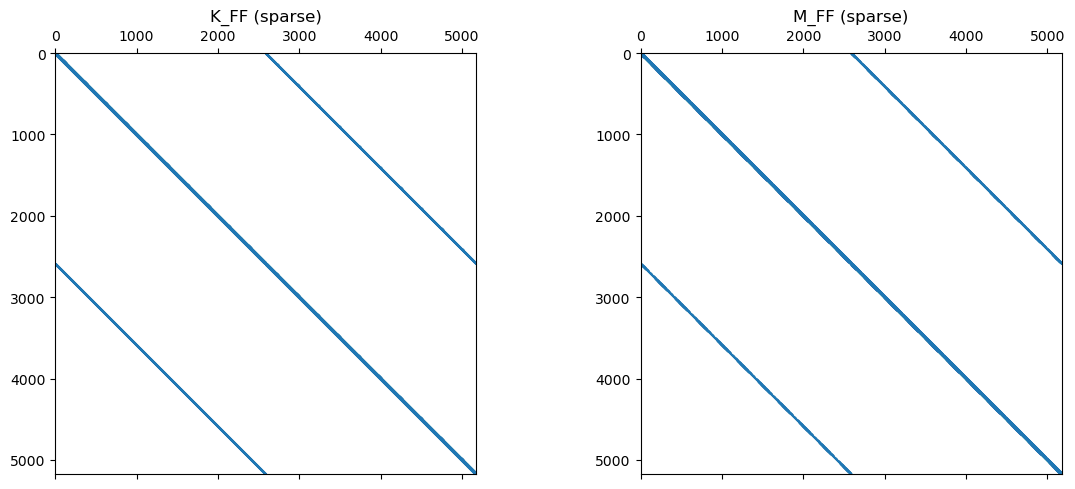

In [20]:


NodesClamp = (0, nNode//2 - 1, nNode//2, nNode - 1)
DofsP = np.array([], dtype=int)
for n0 in NodesClamp:
    # Fix: ux(0), uz(2), rx(3), ry(4), rz(5) — but NOT uy(1)
    DofsP = np.append(DofsP, n0*LDOF + np.array([0, 2, 3, 4, 5]))
DofsF = np.setdiff1d(np.arange(nDof), DofsP)

print(f"Clamped nodes  : {NodesClamp}")
print(f"Prescribed DOFs: {len(DofsP)}")
print(f"Free DOFs      : {len(DofsF)}")

K_sp = sp.csc_matrix(K);  M_sp = sp.csc_matrix(M)
K_FF = K_sp[np.ix_(DofsF, DofsF)]
M_FF = M_sp[np.ix_(DofsF, DofsF)]

print(f"K_FF diag max : {K_FF.diagonal().max():.3e}")
print(f"M_FF diag max : {M_FF.diagonal().max():.3e}")
print(f"M_FF diag min : {M_FF.diagonal().min():.3e}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].spy(K_FF, markersize=0.3); axes[0].set_title("K_FF (sparse)")
axes[1].spy(M_FF, markersize=0.3); axes[1].set_title("M_FF (sparse)")
plt.tight_layout(); plt.show()


## 8. Modal Analysis

In [21]:

L0_mean_valid = L0_nodes[L0_nodes > 0].mean()
EA_moor_nodes_valid = EA_moor_nodes[EA_moor_nodes > 0]

m_per_m = Beam_m_total + 1025 * np.pi * r_o**2   # structural + added mass [kg/m]
Mbay    = m_per_m * 192.0                          # bay mass per tube [kg]

# Compute Kyy at each node using its actual EA and L0
Kyy_nodes = np.zeros(len(L0_nodes))
Kzz_nodes = np.zeros(len(L0_nodes))

for i in range(len(L0_nodes)):
    if L0_nodes[i] == 0:   # skip intermediate nodes
        continue
    ea = EA_moor_nodes[i]
    L0 = L0_nodes[i]
    k_e = ea / L0
    k_g = T0_nl / L0
    Kyy_nodes[i] = 2 * (k_e * np.sin(theta_nl)**2 + k_g * np.cos(theta_nl)**2)
    Kzz_nodes[i] = 2 * (k_e * np.cos(theta_nl)**2 + k_g * np.sin(theta_nl)**2)

# Bay-averaged stiffness (weighted by tributary length — uniform here so just mean)
Kyy_mean = Kyy_nodes[Kyy_nodes > 0].mean()
Kzz_mean = Kzz_nodes[Kzz_nodes > 0].mean()

f_surge = np.sqrt(Kyy_mean / Mbay) / (2 * np.pi)
f_heave = np.sqrt(Kzz_mean / Mbay) / (2 * np.pi)
T_surge = 1 / f_surge
T_heave = 1 / f_heave

f = np.array([f_surge, f_heave])

EA_moor_nl = EA_moor_nodes.mean()

print("=" * 50)
print("MODAL ANALYSIS (depth-varying EA)")
print("=" * 50)
print(f"  m_per_m        = {m_per_m:.0f} kg/m")
print(f"  Mbay           = {Mbay/1e6:.2f} Mt")
print(f"  EA_moor mean   = {EA_moor_nl:.3e} N  (shallow={EA_moor_d:.2e}, deep={EA_moor_s:.2e})")
print(f"  Kyy mean       = {Kyy_mean/1e6:.3f} MN/m")
print(f"  Kzz mean       = {Kzz_mean/1e6:.3f} MN/m")
print()
print(f"  {'Mode':<20} {'f (Hz)':>10} {'T (s)':>8}  Wave band?")
print("  " + "-"*45)
print(f"  {'Surge (lateral)':<20} {f_surge:>10.5f} {T_surge:>8.2f}  {'YES' if 8<=T_surge<=25 else 'NO'}")
print(f"  {'Heave (vertical)':<20} {f_heave:>10.5f} {T_heave:>8.2f}  {'YES' if 8<=T_heave<=25 else 'NO'}")
print()
print(f"  SLS Tp={Tp_1yr}s  → Tp/Tn = {Tp_1yr/T_surge:.2f}")
print(f"  ULS Tp={Tp_5k}s   → Tp/Tn = {Tp_5k/T_surge:.2f}")

n_shallow = np.sum(EA_moor_nodes == EA_moor_d)
n_deep    = np.sum(EA_moor_nodes == EA_moor_s)


MODAL ANALYSIS (depth-varying EA)
  m_per_m        = 321053 kg/m
  Mbay           = 61.64 Mt
  EA_moor mean   = 5.016e+08 N  (shallow=1.70e+09, deep=4.25e+08)
  Kyy mean       = 9.923 MN/m
  Kzz mean       = 9.923 MN/m

  Mode                     f (Hz)    T (s)  Wave band?
  ---------------------------------------------
  Surge (lateral)         0.06386    15.66  YES
  Heave (vertical)        0.06386    15.66  YES

  SLS Tp=10.7s  → Tp/Tn = 0.68
  ULS Tp=12.7s   → Tp/Tn = 0.81


## 9. Rayleigh Damping

In [22]:

import scipy.sparse as sp

# Convert M and K to dense 
M_FF_arr = M_FF.toarray()   # sparse → dense
K_FF_arr = K_FF.toarray()   # sparse → dense

alpha_R_placeholder = 2.0 * 0.05 * (2 * np.pi / 10.7)
C_FF_arr = alpha_R_placeholder * M_FF_arr

print(f"M_FF_arr shape : {M_FF_arr.shape}  max diag = {M_FF_arr.diagonal().max():.3e}")
print(f"K_FF_arr shape : {K_FF_arr.shape}  max diag = {K_FF_arr.diagonal().max():.3e}")
print(f"C_FF_arr initialised as placeholder — will be overridden in Cell 29")

M_FF_arr shape : (5176, 5176)  max diag = 2.351e+09
K_FF_arr shape : (5176, 5176)  max diag = 2.912e+12
C_FF_arr initialised as placeholder — will be overridden in Cell 29


## 10. Wave Kinematics and Morison Force

SLS simulation duration : 600s (56.1 wave periods)
ULS simulation duration : 600s (47.2 wave periods)


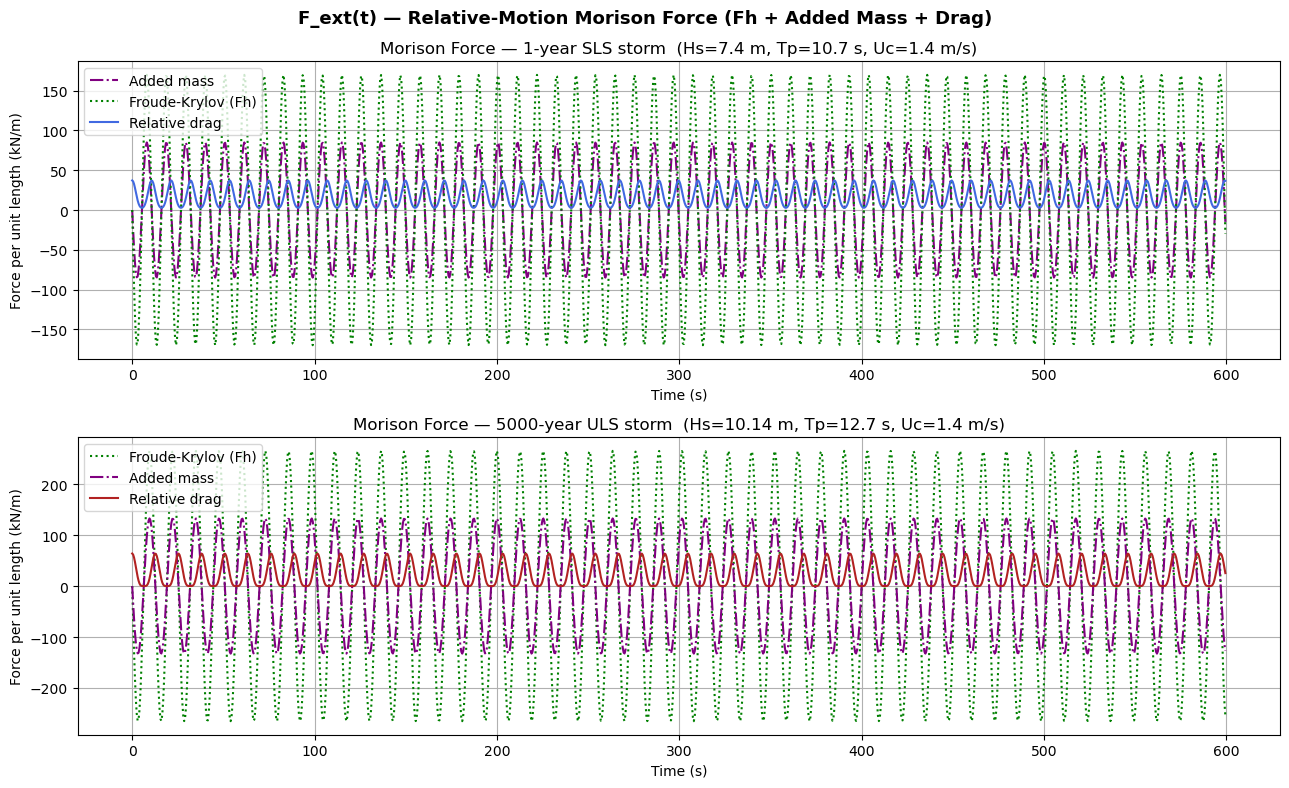

Wave number k (1yr)          : 0.03515 rad/m
Wave number k (5000yr)       : 0.02495 rad/m
Orbital velocity amp (1yr)   : 0.7981 m/s
Orbital velocity amp (5000yr): 1.4795 m/s
1-yr    peak Morison force   : 185.77 kN/m
5000-yr peak Morison force   : 282.40 kN/m


In [23]:

g     = 9.81
rho_w = 1025.0
Cd    = 1.0        # drag coefficient
Cm    = 2.0        # inertia coefficient (= 1 + Ca)
Ca    = Cm - 1.0   # added mass coefficient
D     = 2 * r_o    # outer diameter [m]
z0    = -47.5      # tunnel depth below MSL [m]
ydot = 0.0


# Time arrays
dt       = 0.5
T_1yr    = max(600.0, 15 * Tp_1yr)   # at least 15 wave periods
T_5000yr = max(600.0, 15 * Tp_5k)    # at least 15 wave periods
t_1yr    = np.arange(0, T_1yr,    dt)
t_5000yr = np.arange(0, T_5000yr, dt)
print(f"SLS simulation duration : {T_1yr:.0f}s ({T_1yr/Tp_1yr:.1f} wave periods)")
print(f"ULS simulation duration : {T_5000yr:.0f}s ({T_5000yr/Tp_5k:.1f} wave periods)")


dw = 200.0
k1 = w1**2 / g
for _ in range(50):
    k1 = w1**2 / (g * np.tanh(k1 * dw))

k5 = w5**2 / g
for _ in range(50):
    k5 = w5**2 / (g * np.tanh(k5 * dw))

# --- Orbital velocity and acceleration at tunnel depth z0 ---
amp1   = (np.pi*H_1yr/Tp_1yr)             * np.cosh(k1*(dw+z0)) / np.sinh(k1*dw)
aamp1  = (2*np.pi**2*H_1yr/Tp_1yr**2)     * np.cosh(k1*(dw+z0)) / np.sinh(k1*dw)

amp5   = (np.pi*H_5k/Tp_5k)               * np.cosh(k5*(dw+z0)) / np.sinh(k5*dw)
aamp5  = (2*np.pi**2*H_5k/Tp_5k**2)       * np.cosh(k5*(dw+z0)) / np.sinh(k5*dw)

# --- Relative-motion Morison force per unit length [N/m] ---
# 1-year storm
uI_1   = Uc_1yr + amp1  * np.cos(w1 * t_1yr)       # total water velocity
duI_1  =         -aamp1 * np.sin(w1 * t_1yr)        # water acceleration

Fh_1     = rho_w * Cm   * np.pi/4 * D**2 * duI_1                          # Froude-Krylov + diffraction
F_drag1  = 0.5 * rho_w * Cd * D * (uI_1 - ydot) * np.abs(uI_1 - ydot)   # relative drag
F_1yr    = Fh_1 + F_drag1

# 5000-year storm
uI_5   = Uc_5k + amp5  * np.cos(w5 * t_5000yr)
duI_5  =        -aamp5 * np.sin(w5 * t_5000yr)

Fh_5     = rho_w * Cm   * np.pi/4 * D**2 * duI_5
F_am_5   = rho_w * Ca   * np.pi/4 * D**2 * duI_5
F_drag5  = 0.5 * rho_w * Cd * D * (uI_5 - ydot) * np.abs(uI_5 - ydot)
F_5000yr = Fh_5 + F_drag5

# --- Package for Newmark solver ---
force_series = {
    'SLS_1yr':  (t_1yr,    F_1yr),
    'ULS_5000': (t_5000yr, F_5000yr),
}
cases = {
    'SLS_1yr':  {'label': '1-year storm  (SLS)'},
    'ULS_5000': {'label': '5000-year storm (ULS)'},
}

# --- Plot ---
fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=False)
F_am_1 = rho_w * Ca * np.pi/4 * D**2 * duI_1
axes[0].plot(t_1yr, F_am_1/1e3,  label='Added mass', color='purple', lw=1.5, ls='-.')
axes[0].plot(t_1yr, Fh_1/1e3,    label='Froude-Krylov (Fh)', color='green',     lw=1.5, ls=':')

axes[0].plot(t_1yr, F_drag1/1e3, label='Relative drag',       color='royalblue', lw=1.5)
#axes[0].plot(t_1yr, F_1yr/1e3,   label='Total',               color='black',     lw=2.0)
axes[0].set_ylabel('Force per unit length (kN/m)')
axes[0].set_title(f'Morison Force — 1-year SLS storm  (Hs={Hs_1yr} m, Tp={Tp_1yr} s, Uc={Uc_1yr} m/s)')
axes[0].legend(); axes[0].grid(True); axes[0].set_xlabel('Time (s)')

axes[1].plot(t_5000yr, Fh_5/1e3,    label='Froude-Krylov (Fh)', color='green',    lw=1.5, ls=':')
axes[1].plot(t_5000yr, F_am_5/1e3,  label='Added mass',          color='purple',   lw=1.5, ls='-.')
axes[1].plot(t_5000yr, F_drag5/1e3, label='Relative drag',       color='firebrick',lw=1.5)
#axes[1].plot(t_5000yr, F_5000yr/1e3,label='Total',               color='black',    lw=2.0)
axes[1].set_ylabel('Force per unit length (kN/m)')
axes[1].set_title(f'Morison Force — 5000-year ULS storm  (Hs={Hs_5k} m, Tp={Tp_5k} s, Uc={Uc_5k} m/s)')
axes[1].legend(); axes[1].grid(True); axes[1].set_xlabel('Time (s)')

plt.suptitle('F_ext(t) — Relative-Motion Morison Force (Fh + Added Mass + Drag)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Wave number k (1yr)          : {k1:.5f} rad/m")
print(f"Wave number k (5000yr)       : {k5:.5f} rad/m")
print(f"Orbital velocity amp (1yr)   : {amp1:.4f} m/s")
print(f"Orbital velocity amp (5000yr): {amp5:.4f} m/s")
print(f"1-yr    peak Morison force   : {np.max(np.abs(F_1yr))/1e3:.2f} kN/m")
print(f"5000-yr peak Morison force   : {np.max(np.abs(F_5000yr))/1e3:.2f} kN/m")

In [24]:

def wave_attenuation(k, d, z):
    kd = k * d
    if kd < 0.1:   # shallow water limit — essentially no decay with depth
        return 1.0
    att = np.cosh(k * (d + z)) / np.sinh(kd)
    return min(att, 1.0)   # physically cap at 1.0

att_1yr = wave_attenuation(k1, dw, z0)
att_5k  = wave_attenuation(k5, dw, z0)

print(f"Wave attenuation factor at z={z0} m:")
print(f"  1-yr  storm (k={k1:.5f} rad/m) : {att_1yr:.4f}  ({att_1yr*100:.1f}% of surface)")
print(f"  5000-yr storm (k={k5:.5f} rad/m) : {att_5k:.4f}  ({att_5k*100:.1f}% of surface)")

u_peak_1yr = (np.pi * H_1yr / Tp_1yr) * att_1yr
u_peak_5k  = (np.pi * H_5k  / Tp_5k)  * att_5k

a_peak_1yr = (2 * np.pi**2 * H_1yr / Tp_1yr**2) * att_1yr
a_peak_5k  = (2 * np.pi**2 * H_5k  / Tp_5k**2)  * att_5k

print(f"\nPeak orbital velocity at tunnel depth:")
print(f"  1-yr  : {u_peak_1yr:.4f} m/s  (surface H={H_1yr:.2f} m)")
print(f"  5000-yr: {u_peak_5k:.4f} m/s  (surface H={H_5k:.2f} m)")

F_drag_peak_1yr = 0.5 * rho_w * Cd * D * u_peak_1yr * np.abs(u_peak_1yr)
F_iner_peak_1yr = rho_w * Cm * np.pi/4 * D**2 * a_peak_1yr
F_drag_peak_5k  = 0.5 * rho_w * Cd * D * u_peak_5k * np.abs(u_peak_5k)
F_iner_peak_5k  = rho_w * Cm * np.pi/4 * D**2 * a_peak_5k
F_wave_peak_1yr = F_drag_peak_1yr + F_iner_peak_1yr
F_wave_peak_5k  = F_drag_peak_5k  + F_iner_peak_5k

print(f"\nPeak Morison force per unit length at tunnel depth (drag + inertia):")
print(f"  1-yr   SLS: {F_wave_peak_1yr/1e3:.2f} kN/m  "
      f"(drag={F_drag_peak_1yr/1e3:.2f}, inertia={F_iner_peak_1yr/1e3:.2f})")
print(f"  5000-yr ULS: {F_wave_peak_5k/1e3:.2f} kN/m  "
      f"(drag={F_drag_peak_5k/1e3:.2f}, inertia={F_iner_peak_5k/1e3:.2f})")



Wave attenuation factor at z=-47.5 m:
  1-yr  storm (k=0.03515 rad/m) : 0.1883  (18.8% of surface)
  5000-yr storm (k=0.02495 rad/m) : 0.3058  (30.6% of surface)

Peak orbital velocity at tunnel depth:
  1-yr  : 0.7981 m/s  (surface H=14.43 m)
  5000-yr: 1.4795 m/s  (surface H=19.56 m)

Peak Morison force per unit length at tunnel depth (drag + inertia):
  1-yr   SLS: 174.69 kN/m  (drag=4.90, inertia=169.79)
  5000-yr ULS: 281.98 kN/m  (drag=16.83, inertia=265.16)


## 11. Static Analysis

Static solution (current + buoyancy only):
  Midspan Uy      : 0.4939 m
  Max Uy any node : 1.1643 m
  Max Uz any node : 0.0000 m

  SLS limit check : 1.1643 m ✗ EXCEEDS (limit 1.0 m)


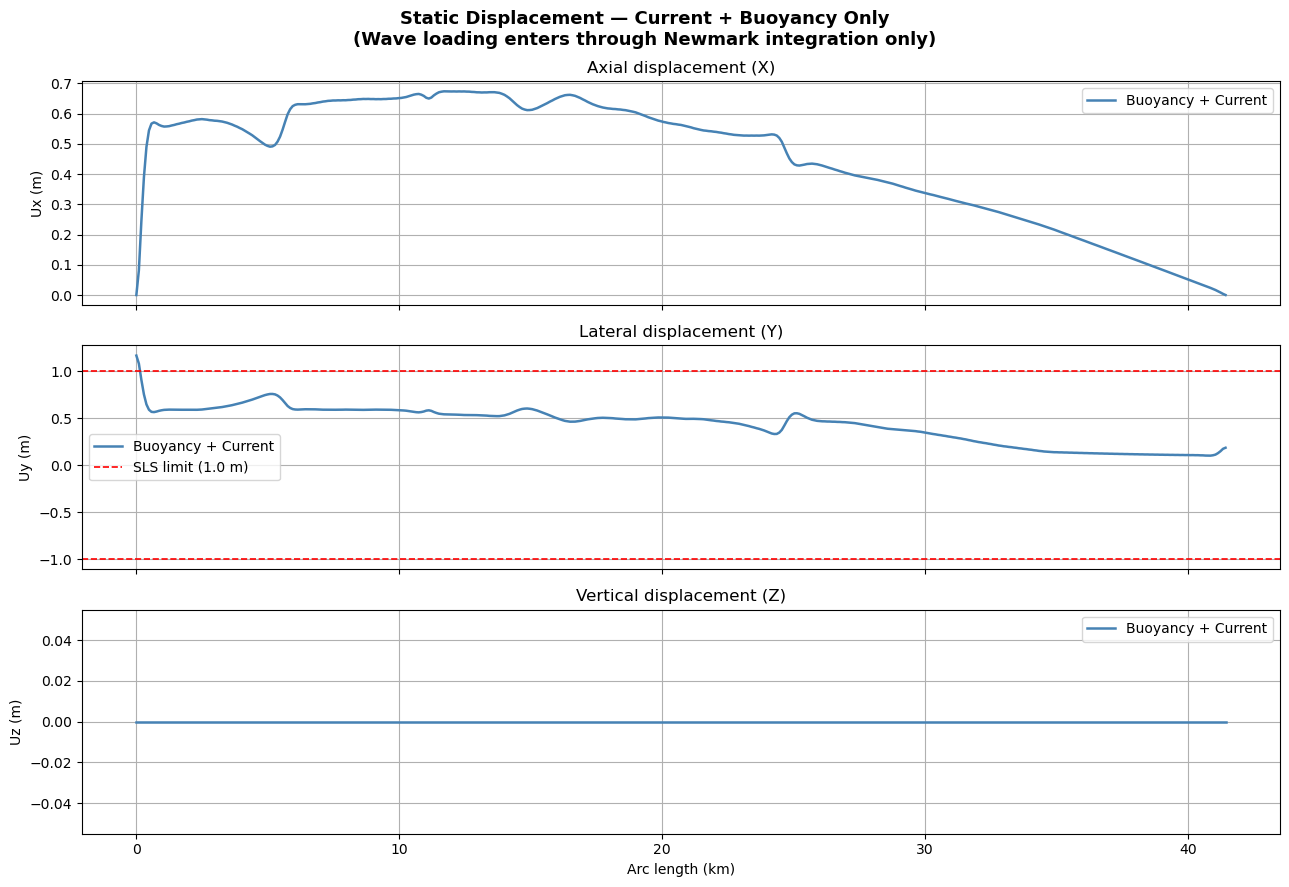

In [25]:

import scipy.sparse.linalg as spla

def build_static_force(q_lat):
    """
    Assemble global static force vector for current drag only.
    Wave loading is NOT included here — it enters through Newmark only.
    
    q_lat : lateral distributed current drag [N/m per tube] → y-direction
    """
    F_global = np.zeros(nDof)
    num_tube_elements = len(Ele) - len(Ele2)
    for iEle in range(num_tube_elements):
        n1 = int(round(Ele[iEle][0]))
        n2 = int(round(Ele[iEle][1]))
        L_e = np.sqrt(sum((NodeC[n2][k] - NodeC[n1][k])**2 for k in range(3)))
        half = L_e / 2.0
        F_global[n1 * LDOF + 1] += q_lat * half   # y lateral — current only
        F_global[n2 * LDOF + 1] += q_lat * half
    return F_global

# Current drag per tube
q_lateral = 0.5 * rho_w * Cd * D * Uc_1yr**2 / 2   # [N/m per tube]


F_global = build_static_force(q_lateral)
F_F      = F_global[DofsF]
U_F      = spla.spsolve(K_FF, F_F)

U_full_static          = np.zeros(nDof)
U_full_static[DofsF]   = U_F

static_results = {
    'Buoyancy + Current': U_full_static
}

mid_node  = nNode // 4
dof_y_mid = mid_node * LDOF + 1
static_offset_mid = abs(U_full_static[dof_y_mid])
static_offset_max = np.max(np.abs(U_full_static[1::LDOF]))

print(f"Static solution (current + buoyancy only):")
print(f"  Midspan Uy      : {static_offset_mid:.4f} m")
print(f"  Max Uy any node : {static_offset_max:.4f} m")
print(f"  Max Uz any node : {np.max(np.abs(U_full_static[2::LDOF])):.4f} m")
print()
print(f"  SLS limit check : {static_offset_max:.4f} m "
      f"{'✓ OK' if static_offset_max <= 1.0 else '✗ EXCEEDS'} (limit 1.0 m)")


U_full = U_full_static

# --- Plot ---
fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=True)

nHalf = nNode // 2
Xo = np.array([n[0] for n in NodeC])
Yo = np.array([n[1] for n in NodeC])
arc_km = np.zeros(nHalf)
for i in range(1, nHalf):
    arc_km[i] = arc_km[i-1] + np.sqrt(
        (Xo[i]-Xo[i-1])**2 + (Yo[i]-Yo[i-1])**2) / 1000.0

Ux = U_full_static[0::LDOF]
Uy = U_full_static[1::LDOF]
Uz = U_full_static[2::LDOF]

axes[0].plot(arc_km, Ux[:nHalf], color='steelblue', lw=1.8,
             label='Buoyancy + Current')
axes[1].plot(arc_km, Uy[:nHalf], color='steelblue', lw=1.8,
             label='Buoyancy + Current')
axes[2].plot(arc_km, Uz[:nHalf], color='steelblue', lw=1.8,
             label='Buoyancy + Current')

# Mark SLS limit on lateral plot
axes[1].axhline(1.0,  color='red', ls='--', lw=1.2, label='SLS limit (1.0 m)')
axes[1].axhline(-1.0, color='red', ls='--', lw=1.2)

axes[0].set_ylabel('Ux (m)');  axes[0].set_title('Axial displacement (X)')
axes[1].set_ylabel('Uy (m)');  axes[1].set_title('Lateral displacement (Y)')
axes[2].set_ylabel('Uz (m)');  axes[2].set_title('Vertical displacement (Z)')

for ax in axes:
    ax.legend(); ax.grid(True)
axes[2].set_xlabel('Arc length (km)')
plt.suptitle('Static Displacement — Current + Buoyancy Only\n'
             '(Wave loading enters through Newmark integration only)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

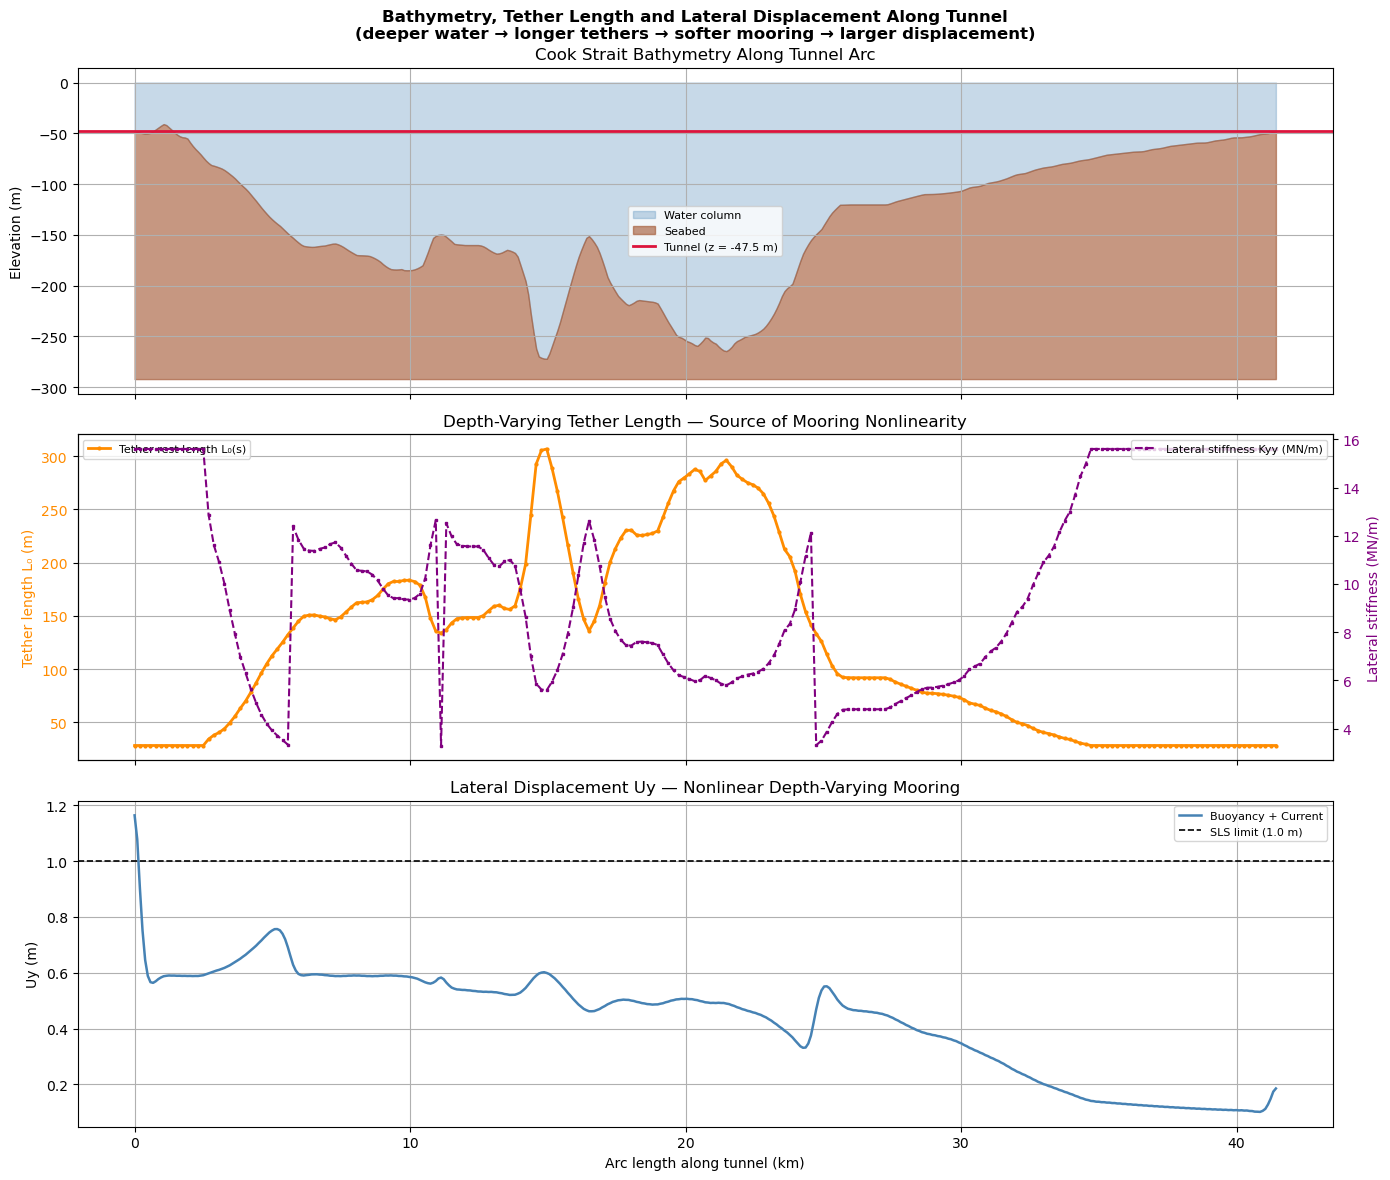

In [26]:

fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)
nHalf   = nNode // 2
arc_km  = np.zeros(nHalf)
Xo = np.array([n[0] for n in NodeC])
Yo = np.array([n[1] for n in NodeC])
for i in range(1, nHalf):
    arc_km[i] = arc_km[i-1] + np.sqrt((Xo[i]-Xo[i-1])**2 + (Yo[i]-Yo[i-1])**2) / 1000


seabed1_plot = seabed_nodes[:nHalf] if len(seabed_nodes) >= nHalf else np.full(nHalf, -200.0)
# --- Panel 1: Seabed depth along tunnel arc ---
try:
    seabed_plot = -seabed1   # use the same seabed1 from cell 11
except NameError:
    seabed_plot = np.full(nHalf, 200.0)

axes[0].fill_between(arc_km, seabed1_plot, 0,
                     alpha=0.3, color='steelblue', label='Water column')
axes[0].fill_between(arc_km, seabed1_plot, seabed1_plot.min()-20,
                     alpha=0.6, color='sienna', label='Seabed')
axes[0].axhline(-47.5, color='crimson', lw=2, label='Tunnel (z = -47.5 m)')
axes[0].set_ylabel('Elevation (m)')
axes[0].set_title('Cook Strait Bathymetry Along Tunnel Arc')
axes[0].legend(fontsize=8); axes[0].grid(True)

# --- Panel 2: Tether length along arc (shows mooring nonlinearity) ---
try:
    L0_plot = L0_nodes[:nHalf].copy()
except NameError:
    alpha_t = np.radians(45.0)
    L0_plot = np.maximum(-seabed1_plot - 47.5, 10.0) / np.cos(alpha_t)

ax2b = axes[1].twinx()

# Filter out zero entries (intermediate non-mooring nodes)
mask = L0_plot > 0
axes[1].plot(arc_km[mask], L0_plot[mask], color='darkorange', lw=2.0,
             label='Tether rest length L₀(s)', marker='o', markersize=2)
axes[1].set_ylabel('Tether length L₀ (m)', color='darkorange')
axes[1].tick_params(axis='y', labelcolor='darkorange')
axes[1].set_title('Depth-Varying Tether Length — Source of Mooring Nonlinearity')
axes[1].grid(True)

# Mooring stiffness (Kyy ~ 1/L0)
try:
    k_yy_plot = np.array([
        2 * (EA_moor_nodes[i] / L0_nodes[i] * np.sin(theta_nl)**2
           + T0_nl            / L0_nodes[i] * np.cos(theta_nl)**2)
        if L0_nodes[i] > 0 else 0.0
        for i in range(nHalf)
    ]) / 1e6
    mask_k = k_yy_plot > 0
    ax2b.plot(arc_km[mask_k], k_yy_plot[mask_k], color='purple', lw=1.5,
              ls='--', marker='s', markersize=2,
              label='Lateral stiffness Kyy (MN/m)')
    ax2b.set_ylabel('Lateral stiffness (MN/m)', color='purple')
    ax2b.tick_params(axis='y', labelcolor='purple')
    axes[1].legend(loc='upper left', fontsize=8)
    ax2b.legend(loc='upper right', fontsize=8)
except Exception:
    axes[1].legend(fontsize=8)

# --- Panel 3: Lateral displacement Uy for all three cases ---
colors_p = ['steelblue', 'orange', 'firebrick']
labels_p = ['Buoyancy + Current', 'SLS (+ 1-yr wave)', 'ULS (+ 5000-yr wave)']

try:
    results_to_plot = static_results   # from nonlinear static cell
    title_str = 'Lateral Displacement Uy — Nonlinear Depth-Varying Mooring'
except NameError:
    results_to_plot = {}
    title_str = 'Lateral Displacement Uy'

for (lc_name, U_f), col in zip(static_results.items(), colors_p):
    Uy_ = U_f[1::LDOF]
    axes[2].plot(arc_km, Uy_[:nHalf], color=col, lw=1.8, label=lc_name)

axes[2].axhline(1.0, color='black', lw=1.2, ls='--', label='SLS limit (1.0 m)')
axes[2].set_ylabel('Uy (m)')
axes[2].set_title(title_str)
axes[2].set_xlabel('Arc length along tunnel (km)')
axes[2].legend(fontsize=8); axes[2].grid(True)

plt.suptitle('Bathymetry, Tether Length and Lateral Displacement Along Tunnel\n'
             '(deeper water → longer tethers → softer mooring → larger displacement)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


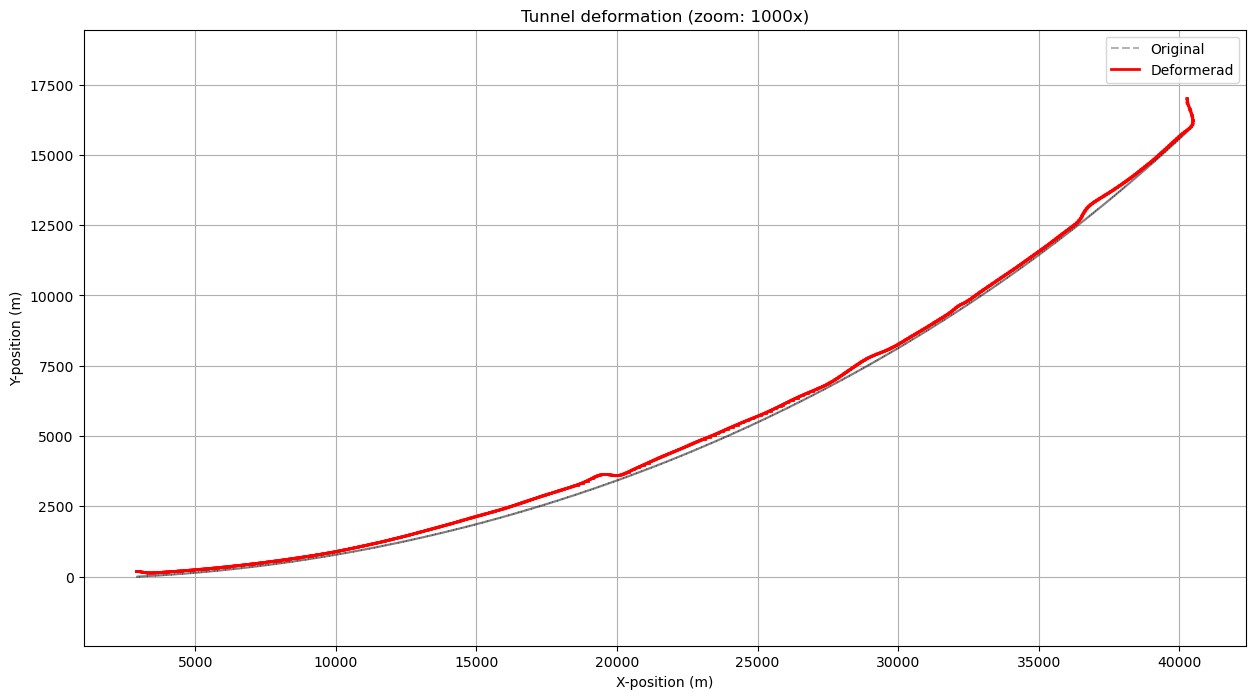

In [27]:

# 1. Convert NodeC to numpy-array to index/add correct
NodeC_arr = np.array(NodeC) 

# 2. Reshape U_full (translate 1D-vector to nodes + 6 DOF per node)
U_reshaped = U_full.reshape((nNode, 6))

# 3. Extract translations (X, Y, Z)
translations = U_reshaped[:, 0:3]

# The scale factor
scale_factor = 1000
Node_def = NodeC_arr + (translations * scale_factor)

# 5. Create the figure
plt.figure(figsize=(15, 8))

# The plot
for i, el in enumerate(Ele):
    n1, n2 = int(el[0]), int(el[1])
    
    # Plot original
    plt.plot([NodeC_arr[n1, 0], NodeC_arr[n2, 0]], 
             [NodeC_arr[n1, 1], NodeC_arr[n2, 1]], 
             'k--', alpha=0.3, label='Original' if i == 0 else "")
             
    # Plot deformed
    plt.plot([Node_def[n1, 0], Node_def[n2, 0]], 
             [Node_def[n1, 1], Node_def[n2, 1]], 
             'r-', linewidth=2, label='Deformerad' if i == 0 else "")

plt.title(f"Tunnel deformation (zoom: {scale_factor}x)")
plt.xlabel("X-position (m)")
plt.ylabel("Y-position (m)")
plt.legend() # The legend
plt.grid(True)
plt.axis('equal') # Important for the scale to be correct
plt.show()

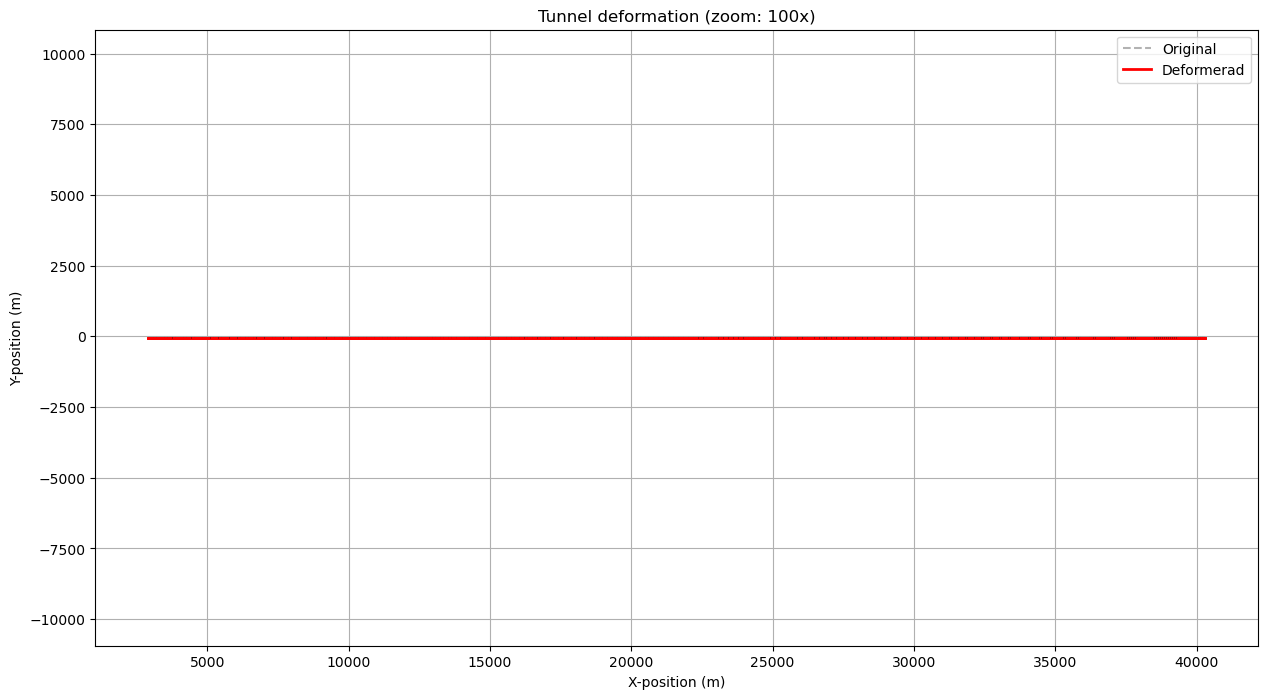

In [28]:

# 1. Convert NodeC to numpy-array to indexe/add correct
NodeC_arr = np.array(NodeC) 

# 2. Reshape U_full (translate 1D-vektor to nodes + 6 DOF per node)
U_reshaped = U_full.reshape((nNode, 6))

# 3. Extract translations (X, Y, Z)
translations = U_reshaped[:, 0:3]

# The scale factor
scale_factor = 100
Node_def = NodeC_arr + (translations * scale_factor)

# 5. Create the figure
plt.figure(figsize=(15, 8))

# The plot
for i, el in enumerate(Ele):
    n1, n2 = int(el[0]), int(el[1])
    
    # Plot original
    plt.plot([NodeC_arr[n1, 0], NodeC_arr[n2, 0]], 
             [NodeC_arr[n1, 2], NodeC_arr[n2, 2]], 
             'k--', alpha=0.3, label='Original' if i == 0 else "")
             
    # Plot deformed
    plt.plot([Node_def[n1, 0], Node_def[n2, 0]], 
             [Node_def[n1, 2], Node_def[n2, 2]], 
             'r-', linewidth=2, label='Deformerad' if i == 0 else "")

plt.title(f"Tunnel deformation (zoom: {scale_factor}x)")
plt.xlabel("X-position (m)")
plt.ylabel("Y-position (m)")
plt.legend() # The legend
plt.ylim(-250, 250) # Zoom in on the middle section
plt.grid(True)
plt.axis('equal') # Important for the scale to be correct
plt.show()

In [29]:

import scipy.linalg as la

# 1. Define a helper function to get the correct 12x12 Transformation Matrix
def get_transformation_matrix(Node1, Node2):
    """Creates the 12x12 rotation matrix for a 3D beam element."""
    xl, yl, zl = Node1[0], Node1[1], Node1[2]
    xr, yr, zr = Node2[0], Node2[1], Node2[2]
    L = np.sqrt((xr - xl)**2 + (yr - yl)**2 + (zr - zl)**2)
    
    C = (xr - xl) / L
    S = (yr - yl) / L
    
    # 3x3 Rotation matrix R
    R = np.array([[C, S, 0], 
                  [-S, C, 0], 
                  [0, 0, 1]])
    
    # Use block_diag to safely create the 12x12 T matrix from 3x3 R matrices
    T = la.block_diag(R, R, R, R)
    return T

# 2. Loop through elements and calculate internal forces
internal_forces = [] # Stores forces for all elements

for iEle in range(len(Ele)):
    # Extract properties and node indices
    n1, n2 = int(round(Ele[iEle][0])), int(round(Ele[iEle][1]))
    EA, EIy, EIz, GJ, Im = Ele[iEle][3], Ele[iEle][4], Ele[iEle][5], Ele[iEle][6], Ele[iEle][7]
    
    # Get Global Displacements (u_global) for this element
    dofs = np.concatenate([np.arange(n1*LDOF, n1*LDOF+LDOF), 
                           np.arange(n2*LDOF, n2*LDOF+LDOF)])
    u_global = U_full[dofs]
    
    # Get Transformation Matrix T
    T = get_transformation_matrix(NodeC[n1], NodeC[n2])
    
    # Transform displacements to local coordinate system: u_local = T * u_global
    u_local = T @ u_global
    
    # Get Local Stiffness Matrix K_local (using your defined Beam3DMatrices properties)
    # NOTE: Since Beam3DMatrices returns global matrices, we use the local stiffness construction
    # We call the logic used inside your Beam3DMatrices function here (simplified)
    L = np.sqrt((NodeC[n2][0]-NodeC[n1][0])**2 + (NodeC[n2][1]-NodeC[n1][1])**2 + (NodeC[n2][2]-NodeC[n1][2])**2)
    
    # Local stiffness matrix K_loc (Simplified version)
    # Standard 3D Beam stiffness formulation
    k_loc = np.array([[EA/L, 0, 0, 0, 0, 0, -EA/L, 0, 0, 0, 0, 0], 
                      [0, 12*EIz/L**3, 0, 0, 0, 6*EIz/L**2, 0, -12*EIz/L**3, 0, 0, 0, 6*EIz/L**2], 
                      [0, 0, 12*EIy/L**3, 0, -6*EIy/L**2, 0, 0, 0, -12*EIy/L**3, 0, -6*EIy/L**2, 0], 
                      [0, 0, 0, GJ/L, 0, 0, 0, 0, 0, -GJ/L, 0, 0],
                      [0, 0, -6*EIy/L**2, 0, 4*EIy/L, 0, 0, 0, 6*EIy/L**2, 0, 2*EIy/L, 0], 
                      [0, 6*EIz/L**2, 0, 0, 0, 4*EIz/L, 0, -6*EIz/L**2, 0, 0, 0, 2*EIz/L], 
                      [-EA/L, 0, 0, 0, 0, 0, EA/L, 0, 0, 0, 0, 0], 
                      [0, -12*EIz/L**3, 0, 0, 0, -6*EIz/L**2, 0, 12*EIz/L**3, 0, 0, 0, -6*EIz/L**2], 
                      [0, 0, -12*EIy/L**3, 0, 6*EIy/L**2, 0, 0, 0, 12*EIy/L**3, 0, 6*EIy/L**2, 0], 
                      [0, 0, 0, -GJ/L, 0, 0, 0, 0, 0, GJ/L, 0, 0],                  
                      [0, 0, -6*EIy/L**2, 0, 2*EIy/L, 0, 0, 0, 6*EIy/L**2, 0, 4*EIy/L, 0],
                      [0, 6*EIz/L**2, 0, 0, 0, 2*EIz/L, 0, -6*EIz/L**2, 0, 0, 0, 4*EIz/L]])
    
    # Calculate Local Forces: F_local = k_local * u_local
    f_local = k_loc @ u_local
    internal_forces.append(f_local)

print(f"Calculated internal forces for {len(internal_forces)} elements.")

# Print forces for Element 0 - Corrected Syntax
print("\nForces in Element 0 (Axial N1, Shear Vz1, Moment My1...):")
print(internal_forces[0])

Calculated internal forces for 1297 elements.

Forces in Element 0 (Axial N1, Shear Vz1, Moment My1...):
[ 2.18376892e+07 -6.76731164e+06  0.00000000e+00  0.00000000e+00
  0.00000000e+00 -1.11580237e+09 -2.18376892e+07  6.76731164e+06
  0.00000000e+00  0.00000000e+00  0.00000000e+00  4.66885292e+08]


In [30]:

import pandas as pd


force_labels = [
    "Axial N1 (MN)", "Shear Vy1 (MN)", "Shear Vz1 (MN)", "Torsion T1 (MNm)", "Moment My1 (MNm)", "Moment Mz1 (MNm)",
    "Axial N2 (MN)", "Shear Vy2 (MN)", "Shear Vz2 (MN)", "Torsion T2 (MNm)", "Moment My2 (MNm)", "Moment Mz2 (MNm)"
]

element_index = 150

if element_index < len(internal_forces):
    f_local = internal_forces[element_index]
    
    forces_mn = f_local / 1e6

    df = pd.DataFrame(forces_mn, index=force_labels, columns=["Kraft/Moment"])
    
    print(f"--- Interna krafter för element {element_index} ---")
    display(df.round(3)) # Avrundar till 3 decimaler för läsbarhet
else:
    print(f"Element {element_index} finns inte i modellen.")

--- Interna krafter för element 150 ---


,Kraft/Moment
Axial N1 (MN),-14.710
Shear Vy1 (MN),0.384
Shear Vz1 (MN),0.000
Torsion T1 (MNm),0.000
Moment My1 (MNm),0.000
Moment Mz1 (MNm),13.801
Axial N2 (MN),14.710
Shear Vy2 (MN),-0.384
Shear Vz2 (MN),0.000
Torsion T2 (MNm),0.000


## seismic

Seismic hazard (NZS 1170.5):
  Z=0.4  R=1.8  N=1.0
  PGA = 0.720 g = 7.06 m/s²
  Sa at T_surge = 15.66 s : 0.006 g  = 0.06 m/s²

Accelerogram:
  Peak acc  : 7.064 m/s²  (0.720 g)
  Peak vel  : 0.299 m/s
  Peak disp : 0.223 m

SDOF tunnel model:
  T_surge = 15.66 s  |  f = 0.0639 Hz
  m_eff   = 61.64 × 10^6 kg (one bay)
  k_eff   = 9.923 MN/m
  zeta    = 5%

Seismic SDOF response:
  Peak relative displacement : 0.083 m
  Peak relative velocity     : 0.301 m/s

Tendon ALS check (seismic):
  Mean tether length L0     : 121.5 m
  Kyy mean                  : 9.923 MN/m
  Peak seismic bay force    : 0.826 MN
  Delta T per tendon        : 0.292 MN
  Pretension T0             : 16.300 MN
  Max tendon tension        : 16.592 MN
  Min tendon tension        : 16.008 MN
  MBL (Chapter 3)           : 57.0 MN
  Utilisation T_max/MBL     : 0.291  ✓ OK
  Slack check (T_min > 0)   : ✓ No slack

Combined seismic + current ALS:
  Current bay force         : 2.893 MN
  Seismic bay force         : 0.826 MN

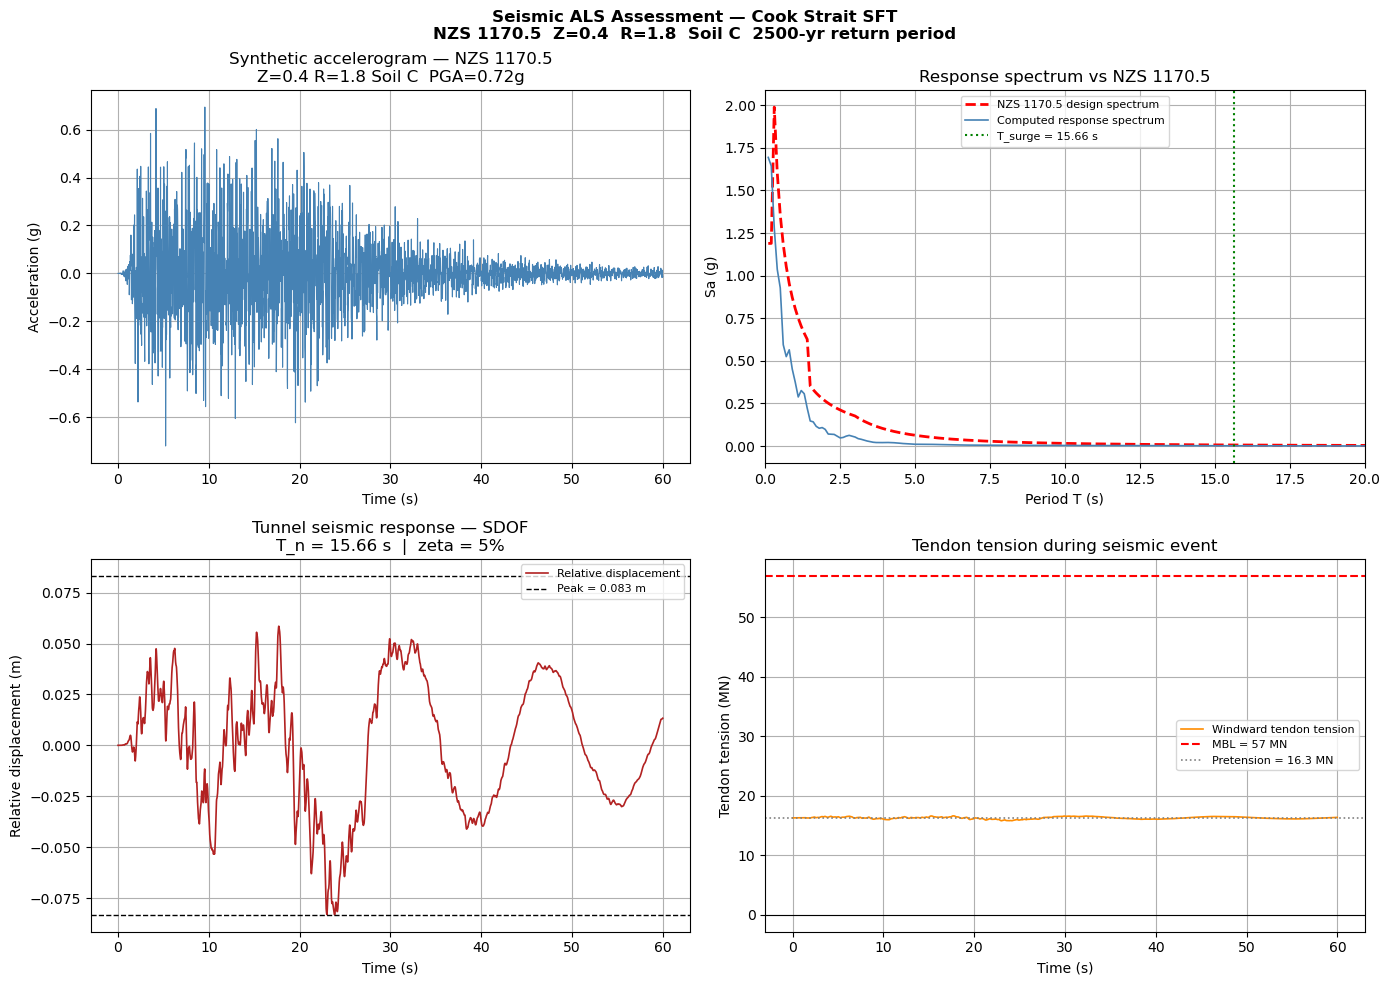


SEISMIC ALS SUMMARY
  Design standard      : NZS 1170.5
  Return period        : 2500 yr
  PGA                  : 0.72 g = 7.06 m/s²
  Tunnel nat. period   : 15.66 s
  Sa at T_surge        : 0.006 g
  Peak seismic disp    : 0.083 m
  Max tendon tension   : 16.592 MN  (seismic only)
  Max tendon tension   : 17.615 MN  (seismic + current)
  MBL                  : 57 MN
  Utilisation          : 0.309  ✓ ALS PASSED
  Slack check          : ✓ No slack


In [31]:


import numpy as np
import matplotlib.pyplot as plt
from numpy.fft import rfft, irfft, rfftfreq

# --- NZS 1170.5 design spectrum parameters ---
Z_seis   = 0.4      # hazard factor (Cook Strait / Wellington)
R_seis   = 1.8      # return period factor (2500 yr ULS)
N_seis   = 1.0      # near-fault factor (distance > 20 km from fault)
S_p_seis = 0.7      # structural performance factor
mu_seis  = 1.0      # ductility (elastic — tunnel is not ductile)
g_acc    = 9.81     # m/s²

PGA      = Z_seis * R_seis * N_seis
a_pga    = PGA * g_acc

# Spectral shape factor Ch(T) for soil class C (NZS 1170.5 Table 3.1)
def Ch_C_seis(T):
    if   T < 0.1:  return 1.33 + 1.60 * T
    elif T < 0.3:  return 2.36
    elif T < 1.5:  return 1.60 / T**0.75
    elif T < 3.0:  return 1.05 / T
    else:          return 3.15 / T**2

print(f"Seismic hazard (NZS 1170.5):")
print(f"  Z={Z_seis}  R={R_seis}  N={N_seis}")
print(f"  PGA = {PGA:.3f} g = {a_pga:.2f} m/s²")
print(f"  Sa at T_surge = {T_surge:.2f} s : "
      f"{Z_seis*R_seis*N_seis*Ch_C_seis(T_surge)*S_p_seis:.3f} g  = "
      f"{Z_seis*R_seis*N_seis*Ch_C_seis(T_surge)*S_p_seis*g_acc:.2f} m/s²")

# --- Synthetic accelerogram ---
dt_eq    = 0.02
T_eq     = 60.0
T_strong = 20.0
t_eq     = np.arange(0, T_eq, dt_eq)
nT_eq    = len(t_eq)

np.random.seed(42)
noise = np.random.randn(nT_eq)

def envelope_seis(t, t1=2.0, t2=20.0, t_end=60.0):
    env = np.zeros_like(t)
    env[t < t1]              = (t[t < t1] / t1)**2
    env[(t >= t1) & (t < t2)] = 1.0
    env[t >= t2]             = np.exp(-2.0 * (t[t >= t2] - t2) / (t_end - t2))
    return env

env   = envelope_seis(t_eq)
noise_shaped = noise * env

freqs_eq      = rfftfreq(nT_eq, d=dt_eq)
freqs_eq[0]   = 1e-6
T_freqs       = 1.0 / freqs_eq
S_target      = np.array([Z_seis * R_seis * N_seis *
                           Ch_C_seis(min(T, 10.0)) * S_p_seis * g_acc
                           for T in T_freqs])

X             = rfft(noise_shaped)
X_scaled      = X / (np.abs(X) + 1e-12) * S_target * np.sqrt(nT_eq * dt_eq) / (2*np.pi)
a_g_raw       = irfft(X_scaled, n=nT_eq)
a_g_raw       = a_g_raw / (np.max(np.abs(a_g_raw)) + 1e-12) * a_pga
a_g           = a_g_raw * env
a_g          -= np.mean(a_g)

v_g  = np.cumsum(a_g)  * dt_eq;  v_g -= np.mean(v_g)
d_g  = np.cumsum(v_g)  * dt_eq;  d_g -= d_g[0]

print(f"\nAccelerogram:")
print(f"  Peak acc  : {np.max(np.abs(a_g)):.3f} m/s²  "
      f"({np.max(np.abs(a_g))/g_acc:.3f} g)")
print(f"  Peak vel  : {np.max(np.abs(v_g)):.3f} m/s")
print(f"  Peak disp : {np.max(np.abs(d_g)):.3f} m")


zeta_seis  = 0.05
omega_seis = 2 * np.pi / T_surge
m_seis     = Mbay                          
k_seis     = m_seis * omega_seis**2
c_seis     = 2 * zeta_seis * m_seis * omega_seis

print(f"\nSDOF tunnel model:")
print(f"  T_surge = {T_surge:.2f} s  |  f = {1/T_surge:.4f} Hz")
print(f"  m_eff   = {m_seis/1e6:.2f} × 10^6 kg (one bay)")
print(f"  k_eff   = {k_seis/1e6:.3f} MN/m")
print(f"  zeta    = {zeta_seis*100:.0f}%")

# Newmark integration — earthquake base excitation
b_r  = 0.25;  g_r  = 0.50
q_r  = 0.0;   qd_r = 0.0
qdd_r = (-m_seis * a_g[0] - c_seis * qd_r - k_seis * q_r) / m_seis

q_hist   = np.zeros(nT_eq)
qd_hist  = np.zeros(nT_eq)
q_hist[0] = q_r

for n in range(nT_eq - 1):
    q_p   = q_r  + dt_eq*qd_r  + dt_eq**2*(0.5 - b_r)*qdd_r
    qd_p  = qd_r + dt_eq*(1 - g_r)*qdd_r
    rhs   = (-m_seis * a_g[n+1]
             - c_seis  * qd_p
             - k_seis  * q_p)
    denom = m_seis + g_r*dt_eq*c_seis + b_r*dt_eq**2*k_seis
    qdd_n = rhs / denom
    q_r   = q_p  + b_r  * dt_eq**2 * qdd_n
    qd_r  = qd_p + g_r  * dt_eq    * qdd_n
    qdd_r = qdd_n
    q_hist[n+1]  = q_r
    qd_hist[n+1] = qd_r

peak_seis_disp = np.max(np.abs(q_hist))
peak_seis_vel  = np.max(np.abs(qd_hist))

print(f"\nSeismic SDOF response:")
print(f"  Peak relative displacement : {peak_seis_disp:.3f} m")
print(f"  Peak relative velocity     : {peak_seis_vel:.3f} m/s")


L0_seis    = L0_nodes[L0_nodes > 0].mean()
EA_seis    = EA_moor_nodes[EA_moor_nodes > 0].mean()
T0_seis    = T0_nl                              # pretension per tendon [N]
theta_seis = theta_nl                           # 45 deg

# Horizontal seismic force on one bay
# F_seis = peak_disp * Kyy_mean (restoring stiffness times displacement)
Kyy_seis   = Kyy_nodes[Kyy_nodes > 0].mean()
F_seis_bay = peak_seis_disp * Kyy_seis

# Per-tendon tension change
delta_T_seis = F_seis_bay / (4 * np.cos(theta_seis))
T_max_seis   = T0_seis + delta_T_seis
T_min_seis   = T0_seis - delta_T_seis

# MBL from Chapter 3
MBL = 57e6   # [N]
util_seis = T_max_seis / MBL

print(f"\nTendon ALS check (seismic):")
print(f"  Mean tether length L0     : {L0_seis:.1f} m")
print(f"  Kyy mean                  : {Kyy_seis/1e6:.3f} MN/m")
print(f"  Peak seismic bay force    : {F_seis_bay/1e6:.3f} MN")
print(f"  Delta T per tendon        : {delta_T_seis/1e6:.3f} MN")
print(f"  Pretension T0             : {T0_seis/1e6:.3f} MN")
print(f"  Max tendon tension        : {T_max_seis/1e6:.3f} MN")
print(f"  Min tendon tension        : {T_min_seis/1e6:.3f} MN")
print(f"  MBL (Chapter 3)           : {MBL/1e6:.1f} MN")
print(f"  Utilisation T_max/MBL     : {util_seis:.3f}  "
      f"{'✓ OK' if util_seis < 1.0 else '✗ EXCEEDS'}")
print(f"  Slack check (T_min > 0)   : "
      f"{'✓ No slack' if T_min_seis > 0 else '✗ Slack predicted'}")

# Combined seismic + current ALS check (Chapter 3 approach)
F_current_bay = 0.5 * 1025 * 1.0 * (2*r_o) * Uc_1yr**2 * Lb
F_als_total   = F_seis_bay + F_current_bay
delta_T_als   = F_als_total / (4 * np.cos(theta_seis))
T_max_als     = T0_seis + delta_T_als
util_als      = T_max_als / MBL

print(f"\nCombined seismic + current ALS:")
print(f"  Current bay force         : {F_current_bay/1e6:.3f} MN")
print(f"  Seismic bay force         : {F_seis_bay/1e6:.3f} MN")
print(f"  Total ALS force           : {F_als_total/1e6:.3f} MN")
print(f"  Max tendon tension        : {T_max_als/1e6:.3f} MN")
print(f"  Utilisation T_max/MBL     : {util_als:.3f}  "
      f"{'✓ OK' if util_als < 1.0 else '✗ EXCEEDS'}")

# =============================================================================
# RESPONSE SPECTRUM CHECK
# =============================================================================
T_spec  = np.linspace(0.1, 30.0, 300)
Sa_code = np.array([Z_seis*R_seis*N_seis*Ch_C_seis(T)*S_p_seis*g_acc
                    for T in T_spec])
Sa_num  = np.zeros(len(T_spec))
zeta_rs = 0.05
for i, T_i in enumerate(T_spec):
    w_i   = 2*np.pi / T_i
    q_r   = 0.0;  qd_r = 0.0
    qdd_r = a_g[0]
    q_max = 0.0
    for n in range(nT_eq - 1):
        q_p   = q_r  + dt_eq*qd_r  + dt_eq**2*(0.5-0.25)*qdd_r
        qd_p  = qd_r + dt_eq*(1-0.5)*qdd_r
        rhs   = -a_g[n+1] - 2*zeta_rs*w_i*qd_p - w_i**2*q_p
        c_r   = 1.0/(1 + 0.5*dt_eq*2*zeta_rs*w_i + 0.25*dt_eq**2*w_i**2)
        qdd_r = rhs * c_r
        q_r   = q_p  + 0.25*dt_eq**2*qdd_r
        qd_r  = qd_p + 0.5 *dt_eq   *qdd_r
        q_max = max(q_max, abs(w_i**2 * q_r))
    Sa_num[i] = q_max

# =============================================================================
# PLOTS
# =============================================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Panel 1: accelerogram
axes[0,0].plot(t_eq, a_g/g_acc, lw=0.8, color='steelblue')
axes[0,0].set_ylabel('Acceleration (g)')
axes[0,0].set_xlabel('Time (s)')
axes[0,0].set_title(f'Synthetic accelerogram — NZS 1170.5\n'
                    f'Z={Z_seis} R={R_seis} Soil C  PGA={PGA:.2f}g')
axes[0,0].grid(True)

# Panel 2: response spectrum
axes[0,1].plot(T_spec, Sa_code/g_acc, lw=2.0, color='red',
               ls='--', label='NZS 1170.5 design spectrum')
axes[0,1].plot(T_spec, Sa_num/g_acc,  lw=1.2, color='steelblue',
               label='Computed response spectrum')
axes[0,1].axvline(T_surge, color='green', ls=':', lw=1.5,
                  label=f'T_surge = {T_surge:.2f} s')
axes[0,1].set_xlabel('Period T (s)')
axes[0,1].set_ylabel('Sa (g)')
axes[0,1].set_title('Response spectrum vs NZS 1170.5')
axes[0,1].legend(fontsize=8)
axes[0,1].grid(True)
axes[0,1].set_xlim(0, 20)

# Panel 3: tunnel SDOF displacement time history
axes[1,0].plot(t_eq, q_hist, lw=1.2, color='firebrick',
               label='Relative displacement')
axes[1,0].axhline( peak_seis_disp, color='black', ls='--', lw=1,
                   label=f'Peak = {peak_seis_disp:.3f} m')
axes[1,0].axhline(-peak_seis_disp, color='black', ls='--', lw=1)
axes[1,0].set_ylabel('Relative displacement (m)')
axes[1,0].set_xlabel('Time (s)')
axes[1,0].set_title(f'Tunnel seismic response — SDOF\n'
                    f'T_n = {T_surge:.2f} s  |  zeta = {zeta_seis*100:.0f}%')
axes[1,0].legend(fontsize=8)
axes[1,0].grid(True)

# Panel 4: tendon tension time history
T_tendon_hist = T0_seis + (EA_seis / L0_seis) * q_hist * np.sin(theta_seis)
axes[1,1].plot(t_eq, T_tendon_hist/1e6, lw=1.2, color='darkorange',
               label='Windward tendon tension')
axes[1,1].axhline(MBL/1e6,  color='red',   ls='--', lw=1.5,
                  label=f'MBL = {MBL/1e6:.0f} MN')
axes[1,1].axhline(T0_seis/1e6, color='gray', ls=':', lw=1.2,
                  label=f'Pretension = {T0_seis/1e6:.1f} MN')
axes[1,1].axhline(0, color='black', ls='-', lw=0.8)
axes[1,1].set_ylabel('Tendon tension (MN)')
axes[1,1].set_xlabel('Time (s)')
axes[1,1].set_title('Tendon tension during seismic event')
axes[1,1].legend(fontsize=8)
axes[1,1].grid(True)

plt.suptitle('Seismic ALS Assessment — Cook Strait SFT\n'
             'NZS 1170.5  Z=0.4  R=1.8  Soil C  2500-yr return period',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# =============================================================================
# FINAL SUMMARY
# =============================================================================
print("\n" + "="*60)
print("SEISMIC ALS SUMMARY")
print("="*60)
print(f"  Design standard      : NZS 1170.5")
print(f"  Return period        : 2500 yr")
print(f"  PGA                  : {PGA:.2f} g = {a_pga:.2f} m/s²")
print(f"  Tunnel nat. period   : {T_surge:.2f} s")
print(f"  Sa at T_surge        : "
      f"{Z_seis*R_seis*N_seis*Ch_C_seis(T_surge)*S_p_seis:.3f} g")
print(f"  Peak seismic disp    : {peak_seis_disp:.3f} m")
print(f"  Max tendon tension   : {T_max_seis/1e6:.3f} MN  "
      f"(seismic only)")
print(f"  Max tendon tension   : {T_max_als/1e6:.3f} MN  "
      f"(seismic + current)")
print(f"  MBL                  : {MBL/1e6:.0f} MN")
print(f"  Utilisation          : {util_als:.3f}  "
      f"{'✓ ALS PASSED' if util_als < 1.0 else '✗ ALS FAILED'}")
print(f"  Slack check          : "
      f"{'✓ No slack' if T_min_seis > 0 else '✗ Slack predicted'}")
print("="*60)

## 12. Dynamic Analysis — Newmark-β

In [32]:

number_of_tube_elements = len(Ele) - len(Ele2)

tube_n1 = np.array([int(round(Ele[i][0])) for i in range(number_of_tube_elements)])
tube_n2 = np.array([int(round(Ele[i][1])) for i in range(number_of_tube_elements)])
tube_L  = np.array([
    np.sqrt(sum((NodeC[tube_n2[i]][k] - NodeC[tube_n1[i]][k])**2 for k in range(3)))
    for i in range(number_of_tube_elements)
])

# Precompute free-DOF lookup dict once
free_dof_lookup = {int(gdof): fi for fi, gdof in enumerate(DofsF)}

def get_free_idx_arr(nodes):
    return np.array([free_dof_lookup.get(int(n * LDOF + 1), -1) for n in nodes])

fi_y_n1   = get_free_idx_arr(tube_n1)
fi_y_n2   = get_free_idx_arr(tube_n2)
gdof_y_n1 = tube_n1 * LDOF + 1
gdof_y_n2 = tube_n2 * LDOF + 1

print(f"Tube elements precomputed : {number_of_tube_elements}")
print(f"Free y-DOFs at n1         : {np.sum(fi_y_n1 >= 0)}")
print(f"Free y-DOFs at n2         : {np.sum(fi_y_n2 >= 0)}")
# --- Nonlinear mooring restoring force for Newmark loop ---
def mooring_restoring_force(U_full):
    F_moor = np.zeros(nDof)
    nTN = nNode // 2

    for node in range(nNode):
        ref = node % nTN
        if ref % 2 != 0:  
            continue
        z_node  = NodeC[ref][2]
        try:
            d_local = float(node_water_depth[ref])
        except Exception:
            d_local = 200.0

        h_n  = max(d_local + z_node, 10.0)
        L0_n = h_n / np.sin(theta_nl)
        r0_n = h_n / np.tan(theta_nl)

        
        EA_local = EA_moor_d if d_local > 150.0 else EA_moor_s

        n_hat = local_normal(node, NodeC, nTN)
        n_x, n_y = n_hat[0], n_hat[1]

        dof_x = node * LDOF;  dof_y = node * LDOF + 1;  dof_z = node * LDOF + 2
        ux = U_full[dof_x];   uy = U_full[dof_y];        uz = U_full[dof_z]

        for sign in [-1.0, +1.0]:
            ax_ = sign * r0_n * n_x
            ay_ = sign * r0_n * n_y
            dx_ = ux - ax_;  dy_ = uy - ay_
            L_cur = math.sqrt(dx_**2 + dy_**2 + h_n**2)
            if L_cur < 1e-8:
                continue
            dL  = L_cur - L0_n
            T   = T0_nl + EA_local * dL / L0_n   # ← fixed: EA_local not EA_moor_nl
            if T <= 0:
                continue
            F_moor[dof_x] += -T * dx_ / L_cur
            F_moor[dof_y] += -T * dy_ / L_cur
            F_moor[dof_z] += -T * uz   / L_cur

    return F_moor, None

print("mooring_restoring_force defined.")
# Precompute arc-length at each node (run once before Newmark)
arc_s = np.zeros(nNode)
nHalf_arc = nNode // 2
for i in range(1, nHalf_arc):
    arc_s[i] = arc_s[i-1] + np.sqrt(
        sum((NodeC[i][k] - NodeC[i-1][k])**2 for k in range(3)))
for i in range(nHalf_arc, nNode):
    arc_s[i] = arc_s[i - nHalf_arc]   # tube 2 shares same arc-length as tube 1

def build_F_wave(t_n, V_free, Uc_v, amp_v, aamp_v, w_v, T_ramp, k_v=0.0):
    """
    Full relative-motion Morison force at time t_n.
    Includes current drag, wave inertia, wave drag, and structural velocity.
    Load ramp over T_ramp seconds. Spatial wave phase cos(w*t - k*s).
    
    The current Uc_v is included in full — no subtraction of mean drag.
    The static solve already found equilibrium under current drag, and
    the Newmark loop starts from that equilibrium. Any residual mean
    force above the static drag appears as a small mean drift which is
    physically correct (wave-current interaction).
    """
    ramp     = min(t_n / T_ramp, 1.0) if T_ramp > 0 else 1.0
    F_global = np.zeros(nDof)

    for i in range(number_of_tube_elements):
        n1  = int(tube_n1[i])
        n2  = int(tube_n2[i])
        L_e = float(tube_L[i])
        half = L_e / 2.0

        fi1 = int(fi_y_n1[i])
        fi2 = int(fi_y_n2[i])
        yd1 = V_free[fi1] if fi1 >= 0 else 0.0
        yd2 = V_free[fi2] if fi2 >= 0 else 0.0

        # Spatial phase per node
        phase1 = w_v * t_n - k_v * arc_s[n1]
        phase2 = w_v * t_n - k_v * arc_s[n2]

        # Total water velocity = current + wave (wave ramped)
        uI_1 = Uc_v + ramp * amp_v  * np.cos(phase1)
        uI_2 = Uc_v + ramp * amp_v  * np.cos(phase2)

        # Water acceleration = wave acceleration only (current is steady)
        duI_1 = -ramp * aamp_v * np.sin(phase1)
        duI_2 = -ramp * aamp_v * np.sin(phase2)

        # Inertia force (Froude-Krylov + added mass, Cm = 2)
        Fh_1 = rho_w * Cm * np.pi/4 * D**2 * duI_1
        Fh_2 = rho_w * Cm * np.pi/4 * D**2 * duI_2

        # Relative velocity (water minus structure)
        rel_vel_1 = np.clip(uI_1 - yd1, -50.0, 50.0)
        rel_vel_2 = np.clip(uI_2 - yd2, -50.0, 50.0)

        # Drag force
        F_drag_1 = 0.5 * rho_w * Cd * D * rel_vel_1 * abs(rel_vel_1)
        F_drag_2 = 0.5 * rho_w * Cd * D * rel_vel_2 * abs(rel_vel_2)

        # Total force at each node
        F_global[n1 * LDOF + 1] += (Fh_1 + F_drag_1) * half
        F_global[n2 * LDOF + 1] += (Fh_2 + F_drag_2) * half

    return F_global[DofsF]


zeta_target = 0.05   # 5% damping

w_a = 2*np.pi * (1/Tp_5k)    # ULS wave freq = 0.251 rad/s
w_b = 2*np.pi * (1/Tp_1yr)   # SLS wave freq = 0.524 rad/s

# Rayleigh coefficients from two-frequency calibration
alpha_R = zeta_target * 2*w_a*w_b / (w_a + w_b)
beta_R  = zeta_target * 2         / (w_a + w_b)

print(f"Corrected Rayleigh coefficients:")
print(f"  alpha_R = {alpha_R:.6f}")
print(f"  beta_R  = {beta_R:.6f}")

# Verify
print(f"\nDamping ratios after correction:")
for label, w in [('ULS wave', w_a), ('SLS wave', w_b),
                 ('Surge mode', 2*np.pi*f[0]),
                 ('Heave mode', 2*np.pi*f[1])]:
    zeta = 0.5*(alpha_R/w + beta_R*w)
    print(f"  {label:<12}: {zeta*100:.2f}%")

# Rebuild damping matrix
C_FF_arr = alpha_R * M_FF_arr + beta_R * K_FF_arr
print(f"\nC_FF_arr rebuilt. Max value: {np.max(C_FF_arr):.3e}")

Tube elements precomputed : 864
Free y-DOFs at n1         : 864
Free y-DOFs at n2         : 864
mooring_restoring_force defined.
Corrected Rayleigh coefficients:
  alpha_R = 0.026851
  beta_R  = 0.092425

Damping ratios after correction:
  ULS wave    : 5.00%
  SLS wave    : 5.00%
  Surge mode  : 5.20%
  Heave mode  : 5.20%

C_FF_arr rebuilt. Max value: 2.692e+11


In [33]:
dt = 0.5  # time step [s]

# Newmark-beta constants (must be defined before K_eff)
beta_NM  = 0.25
gamma_NM = 0.50

import scipy.linalg as la
import time as time_module
# Rebuild K_eff with corrected damping — must come before lu_factor
C_FF_arr = alpha_R * M_FF_arr + beta_R * K_FF_arr
# Displacement-form Newmark effective stiffness (correct formulation)
K_eff    = (1.0/(beta_NM*dt**2))*M_FF_arr \
         + (gamma_NM/(beta_NM*dt))*C_FF_arr \
         + K_FF_arr
K_eff_lu = la.lu_factor(K_eff)
M_lu     = la.lu_factor(M_FF_arr)

# Verify
print(f"K_eff max diagonal: {np.max(np.diag(K_eff)):.3e}  (should be ~1e12, not 1.0)")
print(f"zeta SLS: {0.5*(alpha_R/(2*np.pi/Tp_1yr) + beta_R*(2*np.pi/Tp_1yr))*100:.1f}%")
print(f"zeta ULS: {0.5*(alpha_R/(2*np.pi/Tp_5k)  + beta_R*(2*np.pi/Tp_5k) )*100:.1f}%")
beta_NM  = 0.25
gamma_NM = 0.50

results_dynamic = {}
''''''
# Effective stiffness — acceleration form
# K_eff * A_{n+1} = R_eff
print(f"K_eff diagonal range: {np.diag(K_eff).min():.3e} — {np.diag(K_eff).max():.3e}")
print(f"M_FF_arr diagonal range: {np.diag(M_FF_arr).min():.3e} — {np.diag(M_FF_arr).max():.3e}")
print(f"K_FF_arr diagonal range: {np.diag(K_FF_arr).min():.3e} — {np.diag(K_FF_arr).max():.3e}")

M_lu = la.lu_factor(M_FF_arr)

print(f"K_eff shape: {K_eff.shape}")
print(f"K_eff diagonal range: {np.diag(K_eff).min():.3e} — {np.diag(K_eff).max():.3e}")
mid_node  = nNode // 4
dof_y_mid = mid_node * LDOF + 1
fi_mid    = free_dof_lookup.get(int(dof_y_mid), None)

for case_key, (t_arr_c, _) in force_series.items():


    label  = cases[case_key]['label']
    Uc_v   = Uc_1yr if case_key == 'SLS_1yr' else Uc_5k
    amp_v  = amp1   if case_key == 'SLS_1yr' else amp5
    aamp_v = aamp1  if case_key == 'SLS_1yr' else aamp5
    w_v    = w1     if case_key == 'SLS_1yr' else w5
    Tp_v   = Tp_1yr if case_key == 'SLS_1yr' else Tp_5k
    k_v    = k1     if case_key == 'SLS_1yr' else k5      # ← ADD THIS LINE
    T_ramp = 5 * Tp_v
    nT = len(t_arr_c)
    nF = len(DofsF)

    # Start from static equilibrium under current + buoyancy
    # This eliminates the slow drift transient
    lc_key = 'Buoyancy + Current'
    if lc_key in static_results:
        U_static_full = static_results[lc_key].copy()
        for fi, gdof in enumerate(DofsF):
            local_dof = gdof % LDOF
            if local_dof >= 3:   # zero rotational DOFs
                U_static_full[gdof] = 0.0
        Y = U_static_full[DofsF].copy()
        print(f"  Initial condition: static '{lc_key}', max|Y0|={np.max(np.abs(Y)):.4f} m")
    else:
        Y = np.zeros(nF)
        print(f"  WARNING: key '{lc_key}' not found — starting from zero")
    V = np.zeros(nF)
    

    # Initial acceleration: M*A0 = F0 - C*V0 - K*Y0
    F_moor_0, _ = mooring_restoring_force(U_static_full)
    F_moor_0_F  = F_moor_0[DofsF]

    F0 = build_F_wave(t_arr_c[0], V, Uc_v, amp_v, aamp_v, w_v, T_ramp, k_v)
    A  = la.lu_solve(M_lu, F0 - C_FF_arr @ V - K_FF_arr @ Y)

    Y_hist = np.zeros((nT, nF))
    V_hist = np.zeros((nT, nF))
    Y_hist[0] = Y
    V_hist[0] = V

    print(f"\nNewmark: {label}  |  steps: {nT}  |  dt: {dt} s")
    print(f"  Initial max|A0| = {np.max(np.abs(A)):.3e} m/s²")
    t0     = time_module.time()
    blowup = False

    for n in range(nT - 1):

        # Predictor
        Y_pred = Y + dt*V + dt**2*(0.5 - beta_NM)*A
        V_pred = V + dt*(1.0 - gamma_NM)*A

        # Wave force at t_{n+1} using predictor velocity
        F_wave = build_F_wave(t_arr_c[n+1], V_pred,
                              Uc_v, amp_v, aamp_v, w_v, T_ramp, k_v)

        
        # Add inside the loop, after mooring call, for ULS only
        if case_key == 'ULS_5000' and n % 50 == 0:
            print(f"  t={t_arr_c[n]:.1f}s  max|Y|={np.max(np.abs(Y)):.3f}  "
                  f"Uy_mid={Y[fi_mid] if fi_mid is not None else 0:.3f}")

        # Effective RHS — acceleration form
        
        # Nonlinear mooring restoring force
        Y_full_pred = np.zeros(nDof)
        Y_full_pred[DofsF] = Y_pred
        F_moor_nl, _ = mooring_restoring_force(Y_full_pred)
        F_moor_nl_F  = F_moor_nl[DofsF]

        # Linear mooring already in K_FF_arr — subtract to avoid double-counting
        F_moor_lin = K_FF_arr @ Y_pred   # this includes beam AND mooring stiffness
        # Net nonlinear correction (replaces the linear mooring portion only)
        R_eff = (F_wave
            + F_moor_nl_F
            - C_FF_arr @ V_pred
            - K_FF_arr @ Y_pred)

        if not np.isfinite(R_eff).all():
            print(f"  Blowup at step {n+1}, t={t_arr_c[n+1]:.1f}s")
            blowup = True
            break

        # Solve K_eff * A_next = R_eff
        A_next = la.lu_solve(K_eff_lu, R_eff)

        # Corrector
        Y = Y_pred + beta_NM * dt**2 * A_next
        V = V_pred + gamma_NM * dt   * A_next
        A = A_next

        Y_hist[n+1] = Y
        V_hist[n+1] = V

        if (n+1) % 200 == 0:
            elapsed = time_module.time() - t0
            print(f"  step {n+1:5d}/{nT-1} | "
                  f"t={t_arr_c[n+1]:6.1f}s | "
                  f"max|Y|={np.max(np.abs(Y)):.4e} m | "
                  f"elapsed={elapsed:.1f}s")

    if not blowup:
        print(f"  Done in {time_module.time()-t0:.1f}s | "
              f"Max displacement = {np.max(np.abs(Y_hist)):.4f} m")

    results_dynamic[case_key] = {'t': t_arr_c, 'Y': Y_hist, 'V': V_hist}

print("\nAll dynamic cases completed.")



K_eff max diagonal: 4.026e+12  (should be ~1e12, not 1.0)
zeta SLS: 5.0%
zeta ULS: 5.0%
K_eff diagonal range: 8.019e+08 — 4.026e+12
M_FF_arr diagonal range: 4.841e+06 — 2.351e+09
K_FF_arr diagonal range: 5.258e+08 — 2.912e+12
K_eff shape: (5176, 5176)
K_eff diagonal range: 8.019e+08 — 4.026e+12
  Initial condition: static 'Buoyancy + Current', max|Y0|=1.1643 m

Newmark: 1-year storm  (SLS)  |  steps: 1200  |  dt: 0.5 s
  Initial max|A0| = 5.111e+01 m/s²
  step   200/1199 | t= 100.0s | max|Y|=1.4982e+00 m | elapsed=27.2s
  step   400/1199 | t= 200.0s | max|Y|=1.2407e+00 m | elapsed=56.0s
  step   600/1199 | t= 300.0s | max|Y|=1.2739e+00 m | elapsed=83.9s
  step   800/1199 | t= 400.0s | max|Y|=1.2651e+00 m | elapsed=112.2s
  step  1000/1199 | t= 500.0s | max|Y|=1.2737e+00 m | elapsed=138.8s
  Done in 166.7s | Max displacement = 13.5407 m
  Initial condition: static 'Buoyancy + Current', max|Y0|=1.1643 m

Newmark: 5000-year storm (ULS)  |  steps: 1200  |  dt: 0.5 s
  Initial max|A0| = 5.1

In [34]:
for case_key in ['SLS_1yr', 'ULS_5000']:
    t   = results_dynamic[case_key]['t']
    Y_h = results_dynamic[case_key]['Y']
    i_ss = np.searchsorted(t, 200.0)
    uy_ss = Y_h[i_ss:, fi_mid]
    mean_dyn  = (np.max(uy_ss) + np.min(uy_ss)) / 2
    amp_dyn   = (np.max(uy_ss) - np.min(uy_ss)) / 2
    static_ref = static_results['Buoyancy + Current'][dof_y_mid]
    print(f"{case_key}:")
    print(f"  Dynamic mean Uy      : {mean_dyn:.3f} m")
    print(f"  Static offset        : {static_ref:.3f} m")
    print(f"  Drift above static   : {mean_dyn - static_ref:.3f} m")
    print(f"  Oscillation amplitude: {amp_dyn:.3f} m")
    print(f"  Peak displacement    : {mean_dyn + amp_dyn:.3f} m")

SLS_1yr:
  Dynamic mean Uy      : 0.683 m
  Static offset        : 0.494 m
  Drift above static   : 0.189 m
  Oscillation amplitude: 0.075 m
  Peak displacement    : 0.758 m
ULS_5000:
  Dynamic mean Uy      : 0.909 m
  Static offset        : 0.494 m
  Drift above static   : 0.415 m
  Oscillation amplitude: 0.077 m
  Peak displacement    : 0.986 m


dict_keys(['SLS_1yr', 'ULS_5000'])


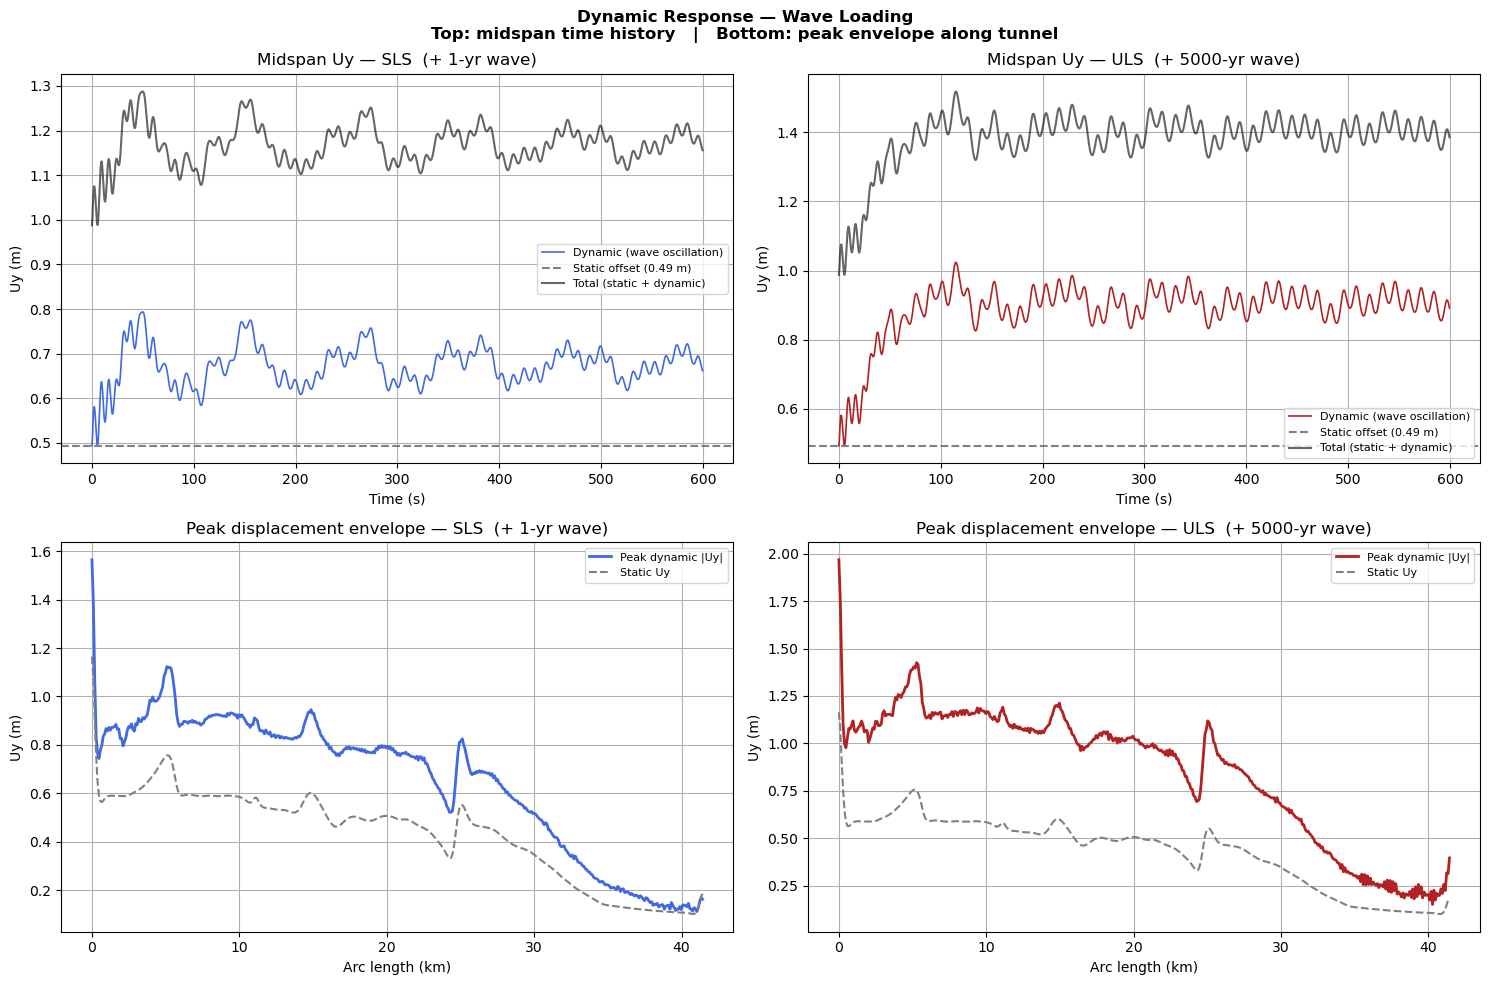


Case                      Static Uy (m)    Peak dyn Uy (m)    Total max (m)  
--------------------------------------------------------------------------
SLS  (+ 1-yr wave)        1.164            1.5647             1.565          
ULS  (+ 5000-yr wave)     1.164            1.9680             1.968          
SLS_1yr:
  Steady-state midspan Uy: min=0.609m  max=0.758m  amplitude=0.075m
  Steady-state max Uy (any node): 1.565m
ULS_5000:
  Steady-state midspan Uy: min=0.832m  max=0.986m  amplitude=0.077m
  Steady-state max Uy (any node): 1.968m


In [35]:

print(results_dynamic.keys())
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
# Ensure arc_km is from nonlinear section
nHalf = nNode // 2
Xo = np.array([n[0] for n in NodeC])
Yo = np.array([n[1] for n in NodeC])
arc_km = np.zeros(nHalf)
for i in range(1, nHalf):
    arc_km[i] = arc_km[i-1] + np.sqrt((Xo[i]-Xo[i-1])**2+(Yo[i]-Yo[i-1])**2)/1000.0
case_keys  = ['SLS_1yr', 'ULS_5000']
lc_names   = ['SLS  (+ 1-yr wave)', 'ULS  (+ 5000-yr wave)']
colors_dyn = ['royalblue', 'firebrick']

mid_node  = nNode // 4          # midspan node of tube 1
dof_y_mid = mid_node * LDOF + 1
fi_mid    = free_dof_lookup.get(int(dof_y_mid), None)

for col_idx, (case_key, lc_name) in enumerate(zip(case_keys, lc_names)):
    t_arr  = results_dynamic[case_key]['t']
    Y_hist = results_dynamic[case_key]['Y']

    # --- Static offset at midspan ---
    U_static = static_results['Buoyancy + Current']
    static_uy_mid = U_static[dof_y_mid] if dof_y_mid < len(U_static) else 0.0

    # --- Dynamic Uy time history at midspan ---
    if fi_mid is not None:
        dyn_uy = Y_hist[:, fi_mid]
    else:
        dyn_uy = np.zeros(len(t_arr))

    total_uy = static_uy_mid + dyn_uy

    # Panel 1: time history at midspan
    axes[0, col_idx].plot(t_arr, dyn_uy,   lw=1.2, color=colors_dyn[col_idx],
                          label='Dynamic (wave oscillation)')
    axes[0, col_idx].axhline(static_uy_mid, lw=1.5, ls='--', color='gray',
                             label=f'Static offset ({static_uy_mid:.2f} m)')
    axes[0, col_idx].plot(t_arr, total_uy,  lw=1.5, color='black', alpha=0.6,
                          label='Total (static + dynamic)')
    axes[0, col_idx].set_title(f'Midspan Uy — {lc_name}')
    axes[0, col_idx].set_xlabel('Time (s)')
    axes[0, col_idx].set_ylabel('Uy (m)')
    axes[0, col_idx].legend(fontsize=8)
    axes[0, col_idx].grid(True)

    # Panel 2: peak dynamic envelope along arc
    i_ss     = np.searchsorted(results_dynamic[case_key]['t'], 200.0)
    peak_dyn = np.max(np.abs(Y_hist[i_ss:]), axis=0)
    peak_full = np.zeros(nDof)
    peak_full[DofsF] = peak_dyn

    axes[1, col_idx].plot(arc_km, peak_full[1::LDOF][:nNode//2],
                          color=colors_dyn[col_idx], lw=2, label='Peak dynamic |Uy|')
    axes[1, col_idx].plot(arc_km, static_results['Buoyancy + Current'][1::LDOF][:nNode//2],
                          color='gray', lw=1.5, ls='--', label='Static Uy')
    axes[1, col_idx].set_title(f'Peak displacement envelope — {lc_name}')
    axes[1, col_idx].set_xlabel('Arc length (km)')
    axes[1, col_idx].set_ylabel('Uy (m)')
    axes[1, col_idx].legend(fontsize=8)
    axes[1, col_idx].grid(True)

plt.suptitle('Dynamic Response — Wave Loading\n'
             'Top: midspan time history   |   Bottom: peak envelope along tunnel',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# Summary table
print(f"\n{'Case':<25} {'Static Uy (m)':<16} {'Peak dyn Uy (m)':<18} {'Total max (m)':<15}")
print("-" * 74)
for case_key, lc_name in zip(case_keys, lc_names):
    t_arr    = results_dynamic[case_key]['t']
    Y_hist   = results_dynamic[case_key]['Y']
    U_static = static_results['Buoyancy + Current']
    # Use steady-state only (after t=200s) to exclude transient
    i_ss = np.searchsorted(t_arr, 200.0)

    static_max = np.max(np.abs(U_static[1::LDOF]))

    # Dynamic peak from y-DOFs only, steady-state only
    fi_y_all = [free_dof_lookup.get(n*LDOF+1) for n in range(nNode)]
    fi_y_all = [fi for fi in fi_y_all if fi is not None]
    dyn_max  = np.max(np.abs(Y_hist[i_ss:, fi_y_all]))

    total_max = dyn_max  # Y already includes static
    print(f"{lc_name:<25} {static_max:<16.3f} {dyn_max:<18.4f} {total_max:<15.3f}")
# Steady-state peak: use only t > 200s to exclude transient
for case_key in ['SLS_1yr', 'ULS_5000']:
    t   = results_dynamic[case_key]['t']
    Y_h = results_dynamic[case_key]['Y']

    # Steady-state index
    i_ss = np.searchsorted(t, 200.0)

    # Midspan only
    if fi_mid is not None:
        uy_ss = Y_h[i_ss:, fi_mid]
        print(f"{case_key}:")
        print(f"  Steady-state midspan Uy: "
              f"min={np.min(uy_ss):.3f}m  max={np.max(uy_ss):.3f}m  "
              f"amplitude={0.5*(np.max(uy_ss)-np.min(uy_ss)):.3f}m")

    # All y-DOFs steady state
    fi_y_all = [free_dof_lookup.get(n*LDOF+1) for n in range(nNode)]
    fi_y_all = [fi for fi in fi_y_all if fi is not None]
    uy_all_ss = Y_h[i_ss:, fi_y_all]
    print(f"  Steady-state max Uy (any node): {np.max(np.abs(uy_all_ss)):.3f}m")

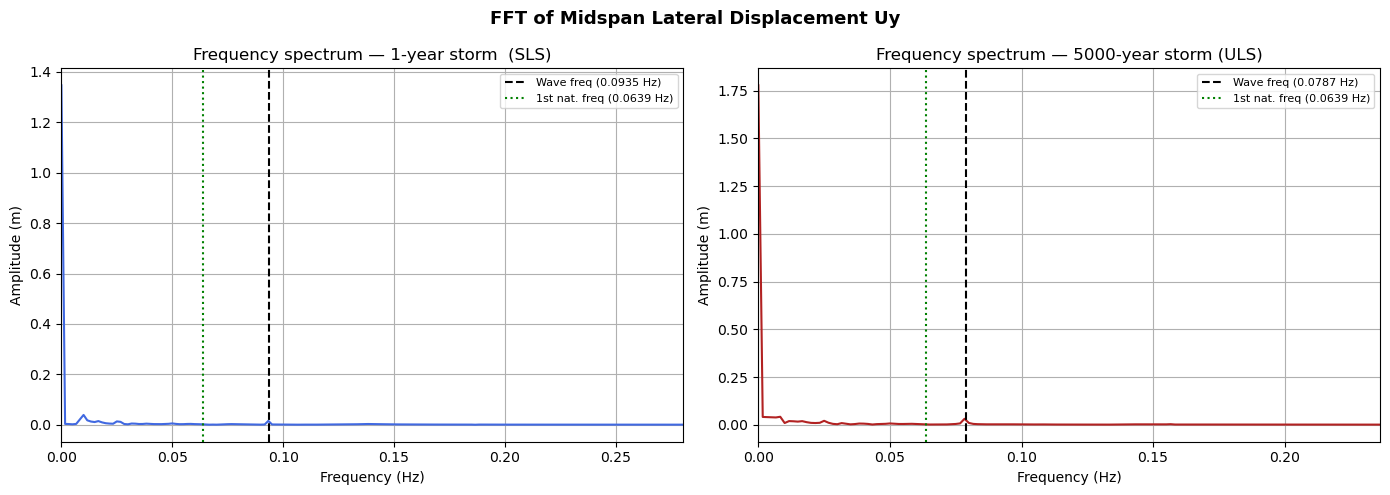

In [36]:

from numpy.fft import rfft, rfftfreq

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, case_key, col in zip(axes, ['SLS_1yr', 'ULS_5000'], ['royalblue', 'firebrick']):
    t_arr  = results_dynamic[case_key]['t']
    Y_hist = results_dynamic[case_key]['Y']

    mid_node  = nNode // 4
    dof_y_mid = mid_node * LDOF + 1
    fi_mid    = free_dof_lookup.get(int(dof_y_mid), None)

    if fi_mid is None:
        print(f"fi_mid not found for {case_key}")
        continue

    uy_t  = Y_hist[:, fi_mid]
    N     = len(uy_t)
    freqs = rfftfreq(N, d=dt)
    amps  = np.abs(rfft(uy_t)) * 2 / N

    ax.plot(freqs, amps, color=col, lw=1.5)

    # Mark wave frequency and first natural frequency
    w_v  = w1 if case_key == 'SLS_1yr' else w5
    f_wave = w_v / (2*np.pi)
    ax.axvline(f_wave, color='black', lw=1.5, ls='--',
               label=f'Wave freq ({f_wave:.4f} Hz)')
    ax.axvline(f[0], color='green', lw=1.5, ls=':',
               label=f'1st nat. freq ({f[0]:.4f} Hz)')

    ax.set_xlabel('Frequency (Hz)')
    ax.set_ylabel('Amplitude (m)')
    ax.set_title(f"Frequency spectrum — {cases[case_key]['label']}")
    ax.legend(fontsize=8); ax.grid(True)
    ax.set_xlim(0, max(f_wave*3, f[0]*3))

plt.suptitle('FFT of Midspan Lateral Displacement Uy',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

1-year storm  (SLS): max |acc| = 0.0478 m/s²  (OK SLS 0.5 m/s² limit)
5000-year storm (ULS): max |acc| = 0.0476 m/s²  (OK SLS 0.5 m/s² limit)


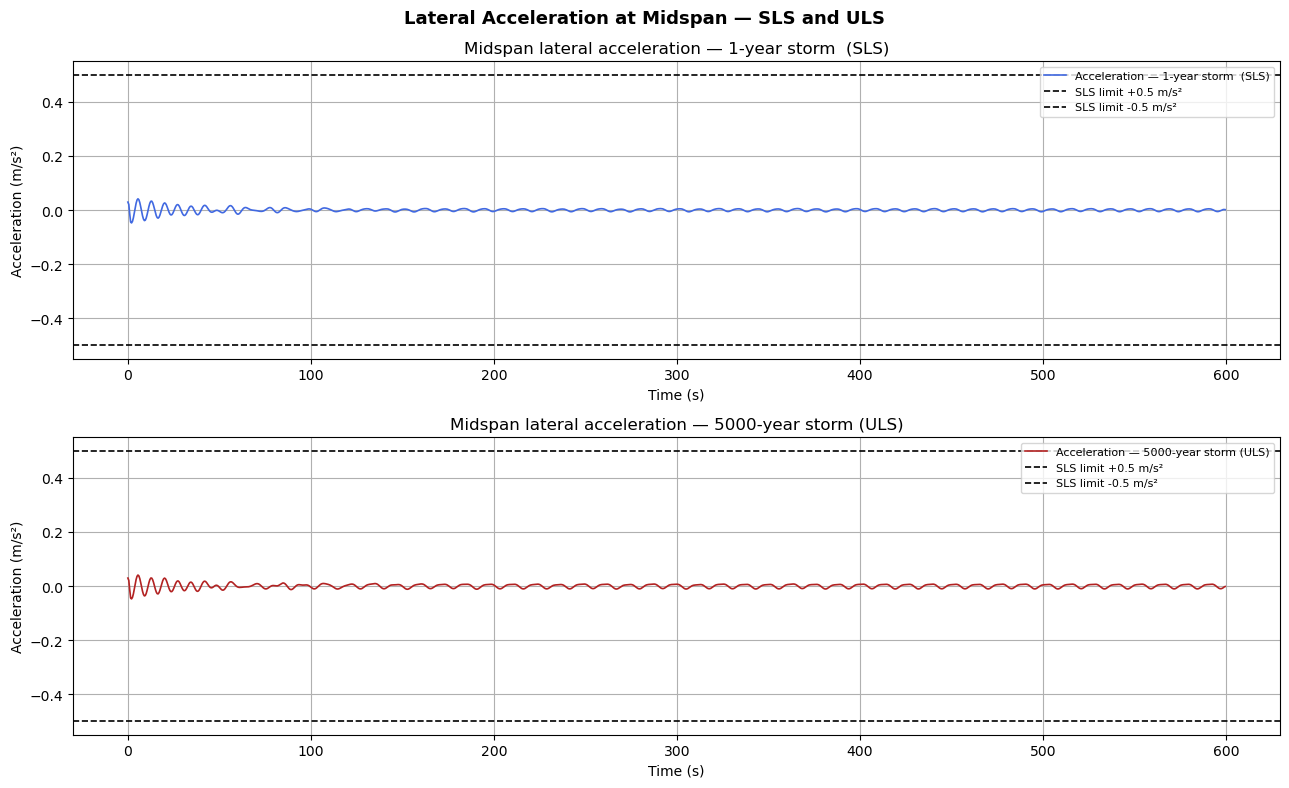

In [37]:

fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=False)

for ax, case_key, col in zip(axes, ['SLS_1yr', 'ULS_5000'], ['royalblue', 'firebrick']):
    t_arr  = results_dynamic[case_key]['t']
    Y_hist = results_dynamic[case_key]['Y']

    mid_node  = nNode // 4
    dof_y_mid = mid_node * LDOF + 1
    fi_mid    = free_dof_lookup.get(int(dof_y_mid), None)

    if fi_mid is None:
        continue

    uy_t = Y_hist[:, fi_mid]

    # Central difference acceleration
    acc = np.gradient(np.gradient(uy_t, dt), dt)

    ax.plot(t_arr, acc, color=col, lw=1.2,
            label=f'Acceleration — {cases[case_key]["label"]}')
    ax.axhline( 0.5, color='black', lw=1.2, ls='--', label='SLS limit +0.5 m/s²')
    ax.axhline(-0.5, color='black', lw=1.2, ls='--', label='SLS limit -0.5 m/s²')

    ax.set_ylabel('Acceleration (m/s²)')
    ax.set_xlabel('Time (s)')
    ax.set_title(f'Midspan lateral acceleration — {cases[case_key]["label"]}')
    ax.legend(fontsize=8); ax.grid(True)

    print(f"{cases[case_key]['label']}: "
          f"max |acc| = {np.max(np.abs(acc)):.4f} m/s²  "
          f"({'EXCEEDS' if np.max(np.abs(acc)) > 0.5 else 'OK'} SLS 0.5 m/s² limit)")

plt.suptitle('Lateral Acceleration at Midspan — SLS and ULS',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Dominant lateral mode : Mode 1
  Natural frequency   : 0.06386 Hz  (T = 15.66 s)
  Effective lat. mass : 9486.96 × 10^6 kg
  Mass fraction       : 100.0%

SDOF ROM:  T_n=15.66 s  |  zeta=5%  |  m=5.852e+09 kg
1-year storm  (SLS): ROM max error vs FEM = 98.7%
5000-year storm (ULS): ROM max error vs FEM = 98.6%


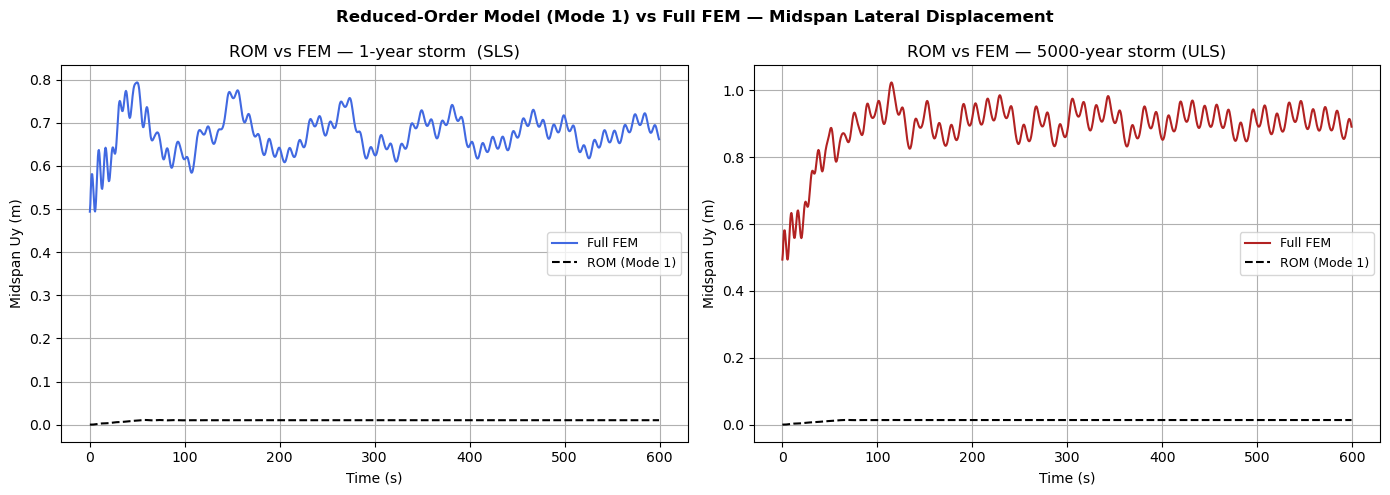

In [38]:

nModes_req = 2


if 'ModalShape' not in dir():
    ModalShape = np.zeros((nDof, nModes_req))
    nHalf_m = nNode // 2
    for j, dof_off in enumerate([1, 2]):   # 1=lateral, 2=vertical
        for n in range(nHalf_m):
            s = n / (nHalf_m - 1)
            phi_val = np.sin(np.pi * s)
            ModalShape[n * LDOF + dof_off, j]             = phi_val
            ModalShape[(n + nHalf_m) * LDOF + dof_off, j] = phi_val
        ModalShape[:, j] /= (np.max(np.abs(ModalShape[:, j])) + 1e-12)

# ── Identify dominant lateral mode ───────────────────────────────────────────
r_lat = np.zeros(len(DofsF))
fi_y_all_rom = [free_dof_lookup.get(n * LDOF + 1) for n in range(nNode)]
fi_y_all_rom = [fi for fi in fi_y_all_rom if fi is not None]
r_lat[fi_y_all_rom] = 1.0

m_modal = np.array([ModalShape[DofsF, j] @ M_FF_arr @ ModalShape[DofsF, j] for j in range(nModes_req)])
L_modal = np.array([ModalShape[DofsF, j] @ M_FF_arr @ r_lat               for j in range(nModes_req)])
m_eff   = L_modal**2 / m_modal
dom_mode = int(np.argmax(m_eff))

print(f"Dominant lateral mode : Mode {dom_mode + 1}")
print(f"  Natural frequency   : {f[dom_mode]:.5f} Hz  (T = {1/f[dom_mode]:.2f} s)")
print(f"  Effective lat. mass : {m_eff[dom_mode]/1e6:.2f} × 10^6 kg")
print(f"  Mass fraction       : {m_eff[dom_mode]/np.sum(m_eff)*100:.1f}%")

# ── SDOF ROM parameters ──────────────────────────────────────────────────────
omega_rom = 2 * np.pi * f[dom_mode]
m_rom     = m_modal[dom_mode]
k_rom     = m_rom * omega_rom**2
zeta_rom  = 0.05
c_rom     = 2 * zeta_rom * m_rom * omega_rom

print(f"\nSDOF ROM:  T_n={2*np.pi/omega_rom:.2f} s  |  zeta={zeta_rom*100:.0f}%  |  m={m_rom:.3e} kg")

# ── Precompute arc-length at each free lateral DOF (for spatial wave phase) ──
# Map free-DOF index → global node index
free_dof_lookup_inv = {fi: int(gdof) for fi, gdof in enumerate(DofsF)}

# Arc-length along tube 1 at each node
nHalf_rom = nNode // 2
arc_length_node = np.zeros(nNode)
for i in range(1, nHalf_rom):
    arc_length_node[i] = arc_length_node[i-1] + np.sqrt(
        sum((NodeC[i][k] - NodeC[i-1][k])**2 for k in range(3))
    )
# Tube 2 nodes share the same arc-length as tube 1
for i in range(nHalf_rom, nNode):
    arc_length_node[i] = arc_length_node[i - nHalf_rom]

# Arc-length at each free lateral DOF entry in fi_y_all_rom
arc_s_rom = np.array([
    arc_length_node[free_dof_lookup_inv[fi] // LDOF]
    for fi in fi_y_all_rom
])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, case_key, col in zip(axes, ['SLS_1yr', 'ULS_5000'], ['royalblue', 'firebrick']):
    Uc_v  = Uc_1yr if case_key == 'SLS_1yr' else Uc_5k
    amp_v = amp1   if case_key == 'SLS_1yr' else amp5
    aamp_v= aamp1  if case_key == 'SLS_1yr' else aamp5
    w_v   = w1     if case_key == 'SLS_1yr' else w5
    k_v   = k1     if case_key == 'SLS_1yr' else k5   # wavenumber for spatial phase
    Tp_v  = Tp_1yr if case_key == 'SLS_1yr' else Tp_5k
    t_rom = results_dynamic[case_key]['t']
    nT_r  = len(t_rom)
    T_ramp = 5* Tp_v

    # ── Modal force time series with spatial wave phase ───────────────────────
    phi_j_free = ModalShape[DofsF, dom_mode]
    f_modal_t  = np.zeros(nT_r)

    for it, t_n in enumerate(t_rom):
        ramp = min(t_n / T_ramp, 1.0)

        # Per-node wave kinematics: cos(w*t - k*s_node)
        phase   = w_v * t_n - k_v * arc_s_rom          # shape (n_lat_dofs,)
        uI_n    = Uc_v + amp_v  * np.cos(phase)         # water velocity  per node
        duI_n   =       -aamp_v * np.sin(phase)         # water accel     per node

        q_n = (rho_w * Cm * np.pi/4 * D**2 * duI_n
              + 0.5 * rho_w * Cd * D * uI_n * np.abs(uI_n)) * ramp  # shape (n_lat_dofs,)

        F_tmp = np.zeros(len(DofsF))
        for idx, fi_n in enumerate(fi_y_all_rom):
            F_tmp[fi_n] += q_n[idx]

        f_modal_t[it] = phi_j_free @ F_tmp

    # ── Newmark SDOF integration ──────────────────────────────────────────────
    dt_r  = t_rom[1] - t_rom[0]
    q_r   = 0.0;  qd_r = 0.0
    qdd_r = (f_modal_t[0] - c_rom * qd_r - k_rom * q_r) / m_rom
    q_hist = np.zeros(nT_r);  q_hist[0] = q_r
    beta_r = 0.25;  gamma_r = 0.5

    for n in range(nT_r - 1):
        q_pred  = q_r  + dt_r*qd_r + dt_r**2*(0.5 - beta_r)*qdd_r
        qd_pred = qd_r + dt_r*(1 - gamma_r)*qdd_r
        rhs     = f_modal_t[n+1] - c_rom*qd_pred - k_rom*q_pred
        qdd_n   = rhs / (m_rom + gamma_r*dt_r*c_rom + beta_r*dt_r**2*k_rom)
        q_r     = q_pred  + beta_r*dt_r**2*qdd_n
        qd_r    = qd_pred + gamma_r*dt_r*qdd_n
        qdd_r   = qdd_n
        q_hist[n+1] = q_r

    # ── Physical midspan displacement ─────────────────────────────────────────
    mid_node_rom = nNode // 4
    dof_y_mid_r  = mid_node_rom * LDOF + 1
    fi_mid_r     = free_dof_lookup.get(int(dof_y_mid_r), None)
    phi_mid      = ModalShape[dof_y_mid_r, dom_mode] if dof_y_mid_r < nDof else 0.0
    u_rom        = phi_mid * q_hist

    Y_hist_fem = results_dynamic[case_key]['Y']
    u_fem = Y_hist_fem[:, fi_mid_r] if fi_mid_r is not None else np.zeros(nT_r)

    ax.plot(t_rom, u_fem, lw=1.5, color=col,     label='Full FEM')
    ax.plot(t_rom, u_rom, lw=1.5, color='black',  ls='--', label=f'ROM (Mode {dom_mode+1})')
    ax.set_title(f"ROM vs FEM — {cases[case_key]['label']}")
    ax.set_xlabel('Time (s)');  ax.set_ylabel('Midspan Uy (m)')
    ax.legend(fontsize=9);  ax.grid(True)

    i_ss  = np.searchsorted(t_rom, 150.0)
    denom = np.max(np.abs(u_fem[i_ss:])) + 1e-9
    err   = np.max(np.abs(u_rom[i_ss:] - u_fem[i_ss:])) / denom * 100
    print(f"{cases[case_key]['label']}: ROM max error vs FEM = {err:.1f}%")

plt.suptitle(f'Reduced-Order Model (Mode {dom_mode+1}) vs Full FEM — Midspan Lateral Displacement',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


Running mesh convergence study...
  n= 100 nodes  spacing=418m  peak Uy=0.3801 m
  n= 200 nodes  spacing=208m  peak Uy=0.4170 m
  n= 341 nodes  spacing=122m  peak Uy=0.4601 m
  n= 433 nodes  spacing=96m  peak Uy=0.4690 m
  n= 500 nodes  spacing=83m  peak Uy=0.4766 m
  n= 700 nodes  spacing=59m  peak Uy=0.4628 m

Change 341 → 433 nodes : 1.89%
Change 433 → 500 nodes : 1.62%  ← convergence check for adopted mesh
Change 500 → 700 nodes : 2.98%

Adopted mesh (n=433, spacing=96 m): Uy = 0.4690 m


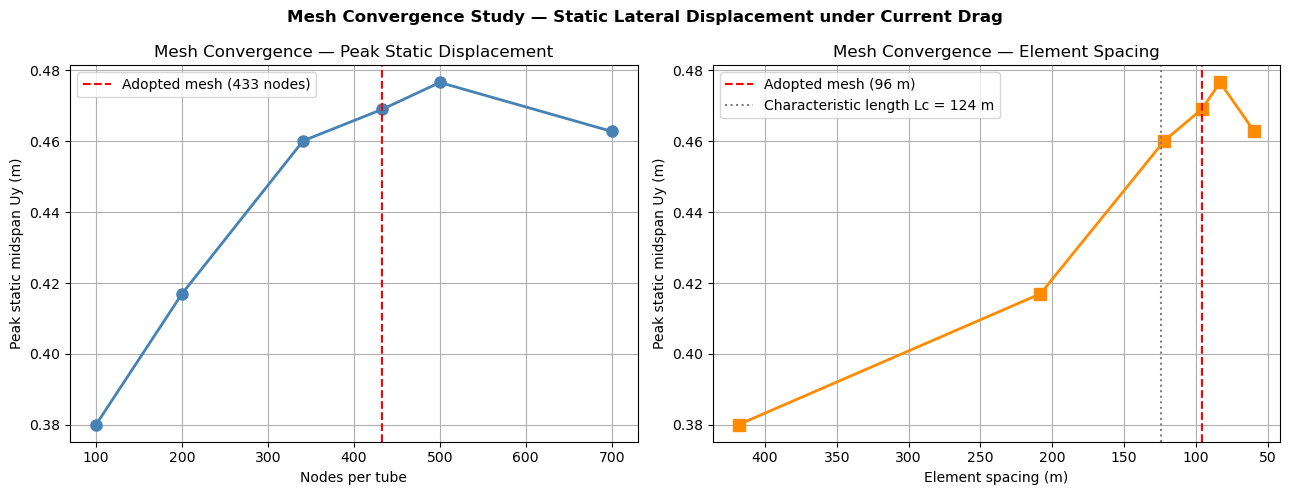

In [42]:
from scipy.sparse.linalg import spsolve

def run_static_mesh(n_nodes_per_tube):

    Xo = np.array([n[0] for n in NodeC])[:nNode//2]
    Yo = np.array([n[1] for n in NodeC])[:nNode//2]
    Zo = np.array([n[2] for n in NodeC])[:nNode//2]

    arc = np.zeros(len(Xo))
    for i in range(1, len(Xo)):
        arc[i] = arc[i-1] + np.sqrt((Xo[i]-Xo[i-1])**2 +
                                     (Yo[i]-Yo[i-1])**2 +
                                     (Zo[i]-Zo[i-1])**2)
    total_arc = arc[-1]

    s_new = np.linspace(0, total_arc, n_nodes_per_tube)
    Xn = np.interp(s_new, arc, Xo)
    Yn = np.interp(s_new, arc, Yo)
    Zn = np.interp(s_new, arc, Zo)

    seabed_interp = np.interp(s_new, arc, seabed_nodes[:len(Xo)])
    node_wd = np.clip(-seabed_interp, 1.0, 400.0)

    NC = [[Xn[i], Yn[i], Zn[i]] for i in range(n_nodes_per_tube)]
    NC += [[Xn[i], Yn[i] + 18.5, Zn[i]] for i in range(n_nodes_per_tube)]
    nN  = len(NC)
    nD  = 6 * nN
    K = lil_matrix((nD, nD))
    for tube_start in [0, n_nodes_per_tube]:
        for i in range(n_nodes_per_tube - 1):
            n1 = tube_start + i
            n2 = tube_start + i + 1
            _, Ke, _ = Beam3DMatrices(
                Beam_m_total, Beam_EA, Beam_EIy, Beam_EIz, Beam_GJ, Beam_Im,
                (NC[n1], NC[n2]))
            dofs = np.r_[n1*6:n1*6+6, n2*6:n2*6+6]
            K[np.ix_(dofs, dofs)] += Ke

    mooring_positions = np.arange(0, total_arc + Lb/2, Lb)

    for m_pos in mooring_positions:
        ref = int(np.argmin(np.abs(s_new - m_pos)))
        if ref >= n_nodes_per_tube:
            continue

        d_node = float(node_wd[ref])
        h_n    = max(d_node + tunnel_depth_z, 1.0)
        L0_n   = h_n / math.sin(theta_nl)

        EA_n   = EA_moor_d if d_node > 150.0 else EA_moor_s
        k_e_n  = EA_n  / L0_n
        k_g_n  = T0_nl / L0_n
        n_hat  = np.array([0., 1., 0.])
        K3     = mooring_stiffness_global(n_hat, k_e_n, k_g_n, theta_vert)

        for tube_offset in [0, n_nodes_per_tube]:
            node = tube_offset + ref
            d3   = [node*6, node*6+1, node*6+2]
            if max(d3) < nD:
                K[np.ix_(d3, d3)] += K3


    K_sp  = sp.csc_matrix(K)
    fixed = []
    for n0 in [0, n_nodes_per_tube-1, n_nodes_per_tube, nN-1]:
        fixed += [n0*6+0, n0*6+2, n0*6+3, n0*6+4, n0*6+5]
    fixed = np.array(fixed, dtype=int)
    free  = np.setdiff1d(np.arange(nD), fixed)
    K_FF  = K_sp[np.ix_(free, free)]

    elem_L = total_arc / (n_nodes_per_tube - 1)
    q_lat  = 0.5 * rho_w * Cd * D * Uc_1yr**2
   
    F      = np.zeros(nD)
    for tube_start in [0, n_nodes_per_tube]:
        for i in range(n_nodes_per_tube - 1):
            n1 = tube_start + i
            n2 = tube_start + i + 1
            F[n1*6+1] += q_lat * elem_L / 2
            F[n2*6+1] += q_lat * elem_L / 2

    F_F = F[free]
    U_F = spsolve(K_FF, F_F)

    # --- Extract midspan Uy ---
    mid          = n_nodes_per_tube // 2
    dof_y_mid_ms = mid * 6 + 1
    fi_ms        = np.where(free == dof_y_mid_ms)[0]
    if len(fi_ms) > 0:
        return float(U_F[fi_ms[0]])
    else:
        return float(np.max(np.abs(U_F[1::6])))


mesh_sizes    = [100, 200, 341, 433, 500, 700]
elem_spacings = []
peak_uy       = []

print("Running mesh convergence study...")
for n in mesh_sizes:
    spacing = submerged_arc_m / (n - 1)
    elem_spacings.append(spacing)
    uy = run_static_mesh(n)
    peak_uy.append(abs(uy))
    print(f"  n={n:4d} nodes  spacing={spacing:.0f}m  peak Uy={abs(uy):.4f} m")

# --- Convergence metrics relative to the adopted mesh (433 nodes) ---
idx_341 = mesh_sizes.index(341)
idx_433 = mesh_sizes.index(433)
idx_500 = mesh_sizes.index(500)
idx_700 = mesh_sizes.index(700)

change_341_433 = abs(peak_uy[idx_433] - peak_uy[idx_341]) / peak_uy[idx_433] * 100
change_433_500 = abs(peak_uy[idx_500] - peak_uy[idx_433]) / peak_uy[idx_433] * 100
change_500_700 = abs(peak_uy[idx_700] - peak_uy[idx_500]) / peak_uy[idx_700] * 100

print(f"\nChange 341 → 433 nodes : {change_341_433:.2f}%")
print(f"Change 433 → 500 nodes : {change_433_500:.2f}%  ← convergence check for adopted mesh")
print(f"Change 500 → 700 nodes : {change_500_700:.2f}%")
print(f"\nAdopted mesh (n=433, spacing={submerged_arc_m/(433-1):.0f} m): "
      f"Uy = {peak_uy[idx_433]:.4f} m")

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(mesh_sizes, peak_uy, 'o-', lw=2, color='steelblue', ms=8)
axes[0].axvline(433, color='red', ls='--',
                label='Adopted mesh (433 nodes)')
axes[0].set_xlabel('Nodes per tube')
axes[0].set_ylabel('Peak static midspan Uy (m)')
axes[0].set_title('Mesh Convergence — Peak Static Displacement')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(elem_spacings, peak_uy, 's-', lw=2, color='darkorange', ms=8)
axes[1].axvline(submerged_arc_m/(433-1), color='red', ls='--',
                label=f'Adopted mesh ({submerged_arc_m/(433-1):.0f} m)')
axes[1].axvline(124, color='gray', ls=':',
                label='Characteristic length Lc = 124 m')
axes[1].set_xlabel('Element spacing (m)')
axes[1].set_ylabel('Peak static midspan Uy (m)')
axes[1].set_title('Mesh Convergence — Element Spacing')
axes[1].invert_xaxis()
axes[1].legend()
axes[1].grid(True)

plt.suptitle('Mesh Convergence Study — Static Lateral Displacement under Current Drag',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()